In [1]:
#c

/tmp/ipykernel_2906/3425441507.py:133: RuntimeWarning: Degrees of freedom <= 0 for slice.
  channel_variance = np.nanvar(wfall, axis=1)
/mnt/d/GCS(trial)/data/chime-frb-open-data-master/venv_chime_frb/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2906/3425441507.py:288: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(fred_model, t_idx, y, p0=p0, maxfev=10000)


       eventname                      pipeline          snr   width_ms  \
0   FRB20180725A         Native (CHIME portal)   311.775313   2.949120   
1   FRB20180725A               B: CHIME Boxcar   400.337608   3.932160   
2   FRB20180725A  A: Optimized Asymmetric FRED    22.786708   0.519562   
3   FRB20180727A         Native (CHIME portal)   148.256974   2.949120   
4   FRB20180727A               B: CHIME Boxcar   272.379619  21.626880   
5   FRB20180727A  A: Optimized Asymmetric FRED     9.249599   1.025330   
6   FRB20180730A         Native (CHIME portal)  1039.461321   4.915200   
7   FRB20180730A               B: CHIME Boxcar  1056.712262   4.915200   
8   FRB20180730A  A: Optimized Asymmetric FRED    22.597586   0.433369   
9   FRB20180801A         Native (CHIME portal)   354.825351   9.830400   
10  FRB20180801A               B: CHIME Boxcar   537.238696  18.677760   
11  FRB20180801A  A: Optimized Asymmetric FRED    14.008807   1.035810   
12  FRB20180806A         Native (CHIME

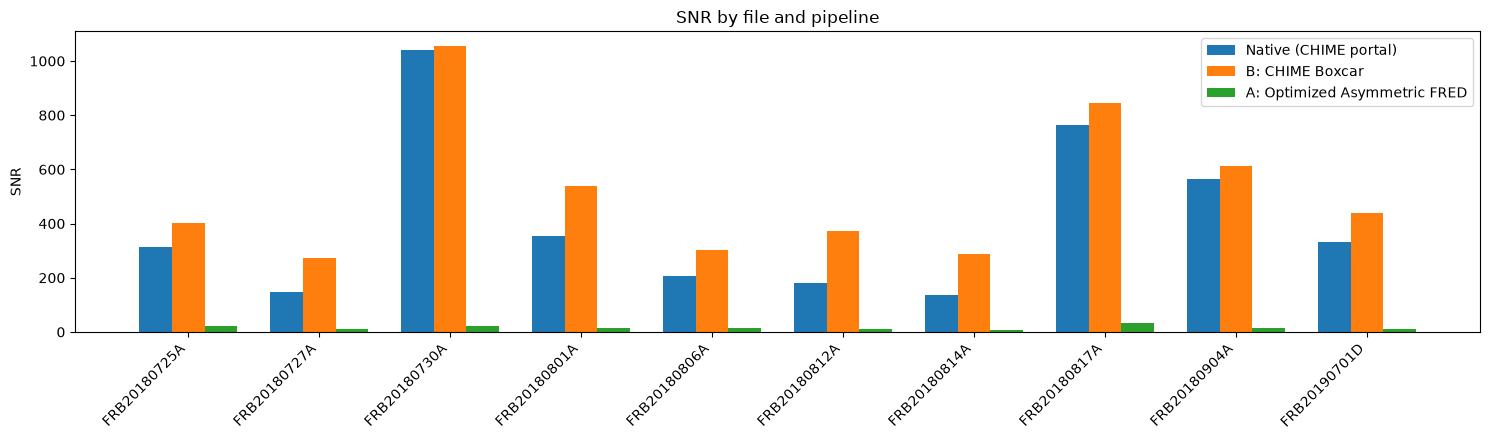

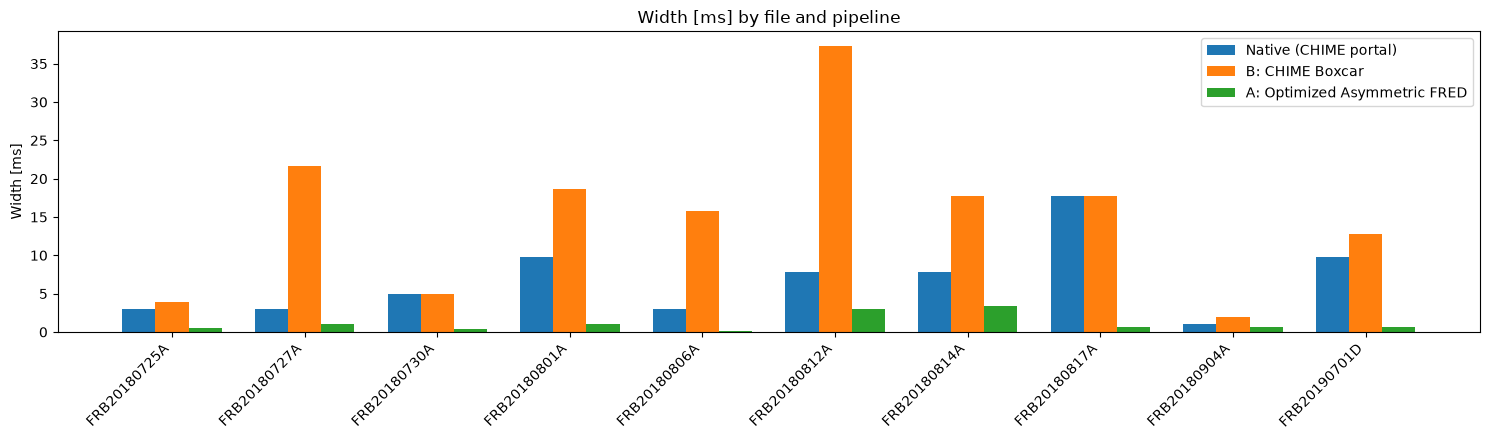

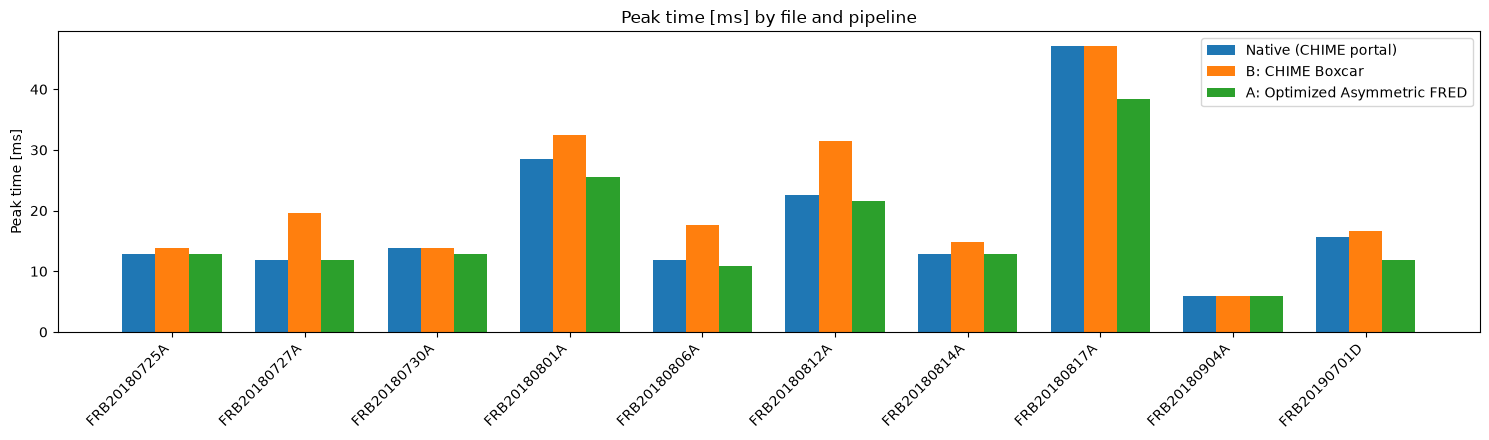

In [3]:
"""
CHIME multi-channel HDF5 pulse-detection pipeline
==================================================

This script implements the flowchart exactly as three branches:

  LEFT   : NATIVE CHIME WEB PORTAL
           -> reproduces CHIME/FRB Open Data "Tutorial 1"
              (https://chime-frb-open-data.github.io/waterfall/) verbatim,
              including its known weaknesses (no detrending, fixed 3x
              variance RFI cut, un-normalized amplitude).

  RIGHT  : YOUR SYSTEM
           Common front-end (steps 1-3) feeds into two competing
           back-ends:
             Pipeline B: CHIME Boxcar        (steps 4,5)
             Pipeline A: Optimized Asymmetric FRED (steps 4a,4b,5)

Every function is tagged with the flowchart box it implements, e.g.
"[STEP 2 - NATIVE]" or "[STEP 4a - PIPELINE A]", so you can map code
back to the diagram directly.

============================== ASSUMPTIONS =================================
The flowchart does not give numeric values for several "your system" boxes.
I picked the following defaults -- change them in the CONFIG block below,
do NOT edit function internals unless you tell me the underlying method
should change:

 1. Local window detrending (Step 1): implemented as a per-channel
    running-median subtraction. Window defaults to 100 ms, i.e. much
    wider than typical ms-scale FRB/pulsar pulses, so the slow drift is
    removed without eating the fast peak.
 2. Adaptive MAD RFI masking (Step 2): flags channels whose robust
    scatter (MAD) deviates from the median channel scatter by more than
    k=5 scaled-MADs (1.4826*MAD ~ sigma for a Gaussian). k is a CONFIG
    value.
 3. Frequency axis aggregation (Step 3): plain np.nansum over frequency,
    same operator as the native branch, just applied to cleaned data.
 4. FRED model (Step 4a): I used the standard "Gaussian rise convolved
    with one-sided exponential decay" pulse shape (an Exponentially
    Modified Gaussian / EMG), because that is the standard closed-form
    asymmetric FRED shape used for scattered radio pulses. sigma = rise
    width, tau = decay time. curve_fit extracts (A, t0, sigma, tau).
 5. Asymmetric FRED filter / template (Step 4b): the fitted EMG curve
    itself, energy-normalized (sum(template**2) = 1) so the correlation
    output is a true matched-filter statistic.
 6. Sliding Index Dot Product (Step 5, Pipeline A): scipy.signal.correlate
    of the time series against the template, followed by an explicit
    index correction for the template's own internal peak offset
    (zero-padding + relabeling), so the reported peak sample is the
    physical peak, not shifted by the asymmetric kernel's group delay.
 7. Noise / SNR normalization: Pipeline B keeps the native tutorial's
    convention (SNR = raw convolved peak amplitude, no explicit noise
    division -- this IS the "rigid, tail-dragged" bias the chart
    describes). Pipeline A divides the matched-filter peak by a robust
    off-pulse noise estimate (1.4826 * MAD of an off-pulse region of the
    time series), giving a true statistical significance, per the box
    label "Maximum significance statistical SNR".

If any of these 7 choices should be different, tell me which one and
what you want instead -- I will not change them speculatively.
==============================================================================
"""

import glob
import os

import h5py
import numpy as np
import pandas as pd
import scipy.signal
from scipy.ndimage import median_filter
from scipy.optimize import curve_fit
from scipy.special import erfc
import matplotlib.pyplot as plt

# ============================================================================
# CONFIG -- edit these, not the function bodies
# ============================================================================
DATA_DIR = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images"  # your waterfall .h5 folder
FILE_PATTERN = "*.h5"        # glob pattern for CHIME waterfall files

RFI_VAR_FACTOR = 3           # native branch, fixed (matches CHIME tutorial)
MAD_K = 5.0                  # your-system adaptive MAD threshold (in scaled-MAD units)
DETREND_WINDOW_MS = 100.0    # your-system local detrending window

BOXCAR_MIN_WIDTH = 1         # samples, native + pipeline B
BOXCAR_MAX_WIDTH = 128       # samples, native + pipeline B

FRED_FIT_WINDOW = 256        # samples on either side of peak used for curve_fit


# ============================================================================
# BLOCK 0  --  [ RAW MULTI-CHANNEL HDF5 DATA ]
# ============================================================================
def load_hdf5(file_name):
    """Read one CHIME/FRB waterfall .h5 file and unpack the arrays used
    downstream by every branch (mirrors the tutorial's "Read hdf5 files"
    section exactly)."""
    with h5py.File(file_name, "r") as f:
        data = f["frb"]
        eventname = data.attrs["tns_name"].decode() if "tns_name" in data.attrs else os.path.basename(file_name)
        wfall = data["wfall"][:].astype(float)
        spec = data["spec"][:].astype(float)
        plot_time = data["plot_time"][:]
        plot_freq = data["plot_freq"][:]
        dm = data.attrs["dm"][()] if "dm" in data.attrs else None

    dt = float(np.median(np.diff(plot_time)))  # ms between time samples
    return {
        "eventname": eventname,
        "wfall": wfall,
        "spec": spec,
        "plot_time": plot_time,
        "plot_freq": plot_freq,
        "dt": dt,
        "dm": dm,
        "file_name": file_name,
    }


# ============================================================================
# LEFT BRANCH -- [ NATIVE CHIME WEB PORTAL ]  (= CHIME/FRB Tutorial 1, verbatim)
# ============================================================================
def native_rfi_mask(wfall, spec, rfi_masking_var_factor=RFI_VAR_FACTOR):
    """[STEP 2 - NATIVE] Fixed statistical filter: flag channels whose
    variance exceeds `rfi_masking_var_factor`x the mean channel variance,
    plus an IQR outlier cut on `spec`. Ported directly from the tutorial."""
    q1 = np.nanquantile(spec, 0.25)
    q3 = np.nanquantile(spec, 0.75)
    iqr = q3 - q1

    channel_variance = np.nanvar(wfall, axis=1)
    mean_channel_variance = np.nanmean(channel_variance)

    with np.errstate(invalid="ignore"):
        rfi_mask = (
            (channel_variance > rfi_masking_var_factor * mean_channel_variance)
            | (spec[::-1] < q1 - 1.5 * iqr)
            | (spec[::-1] > q3 + 1.5 * iqr)
        )
    wfall = wfall.copy()
    wfall[rfi_mask, ...] = np.nan
    return wfall, rfi_mask


def native_frequency_integration(wfall):
    """[STEP 3 - NATIVE] Un-detrended frequency collapse via np.nansum."""
    return np.nansum(wfall, axis=0)


def boxcar_kernel(width):
    """[STEP 5 - NATIVE/PIPELINE B] Flat top-hat kernel, energy-scaled by 1/sqrt(W)."""
    width = int(round(width))
    return np.ones(width, dtype="float64") / np.sqrt(width)


def iterative_boxcar_search(ts, min_width=BOXCAR_MIN_WIDTH, max_width=BOXCAR_MAX_WIDTH):
    """[STEP 4 - NATIVE/PIPELINE B] Iterative integer window loop +
    [STEP 6 - NATIVE / STEP 5 - PIPELINE B] symmetric sliding convolution
    via scipy.signal.convolve. Returns (peak_sample, width, raw_snr)."""
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))

    snrs = np.empty(len(widths), dtype=float)
    peaks = np.empty(len(widths), dtype=int)
    for i, w in enumerate(widths):
        convolved = scipy.signal.convolve(ts, boxcar_kernel(w), mode="same")
        peaks[i] = np.nanargmax(convolved)
        snrs[i] = convolved[peaks[i]]

    best_idx = np.nanargmax(snrs)
    return peaks[best_idx], widths[best_idx], snrs[best_idx]


def run_native_pipeline(file_name):
    """Runs the full LEFT branch end to end and returns raw, un-normalized results."""
    d = load_hdf5(file_name)
    wfall_masked, _ = native_rfi_mask(d["wfall"], d["spec"])
    ts = native_frequency_integration(wfall_masked)
    peak, width, snr = iterative_boxcar_search(ts)
    return {
        "file_name": d["file_name"],
        "eventname": d["eventname"],
        "pipeline": "Native (CHIME portal)",
        "peak_sample": peak,
        "peak_time_ms": peak * d["dt"],
        "width_samples": width,
        "width_ms": width * d["dt"],
        "snr": snr,
    }


# ============================================================================
# RIGHT BRANCH -- [ YOUR SYSTEM: COMMON FRONT-END DEFRAGGING ]
# ============================================================================
def local_window_detrend(wfall, dt, window_ms=DETREND_WINDOW_MS):
    """[STEP 1 - YOUR SYSTEM] Local window detrending: per-channel running
    median subtraction removes slow drift while a fast (ms-scale) peak
    passes through untouched, since the window is much wider than the pulse."""
    window_samples = max(3, int(round(window_ms / dt)))
    if window_samples % 2 == 0:
        window_samples += 1  # median_filter wants an odd kernel
    trend = median_filter(wfall, size=(1, window_samples), mode="nearest")
    return wfall - trend


def adaptive_mad_mask(wfall, k=MAD_K):
    """[STEP 2 - YOUR SYSTEM] Adaptive MAD RFI masking: non-parametric,
    median/MAD based channel flagging (robust to the very spikes that
    break the native branch's mean/variance filter)."""
    channel_scatter = np.nanstd(wfall, axis=1)
    med = np.nanmedian(channel_scatter)
    mad = np.nanmedian(np.abs(channel_scatter - med))
    scaled_mad = 1.4826 * mad if mad > 0 else np.nanstd(channel_scatter)

    with np.errstate(invalid="ignore"):
        mask = np.abs(channel_scatter - med) > k * scaled_mad

    wfall = wfall.copy()
    wfall[mask, ...] = np.nan
    return wfall, mask


def aggregate_frequency(wfall_clean):
    """[STEP 3 - YOUR SYSTEM] Frequency axis aggregation on cleaned data."""
    return np.nansum(wfall_clean, axis=0)


def common_front_end(d):
    """Runs steps 1-3 of the right branch and returns the cleaned time series."""
    detrended = local_window_detrend(d["wfall"], d["dt"])
    masked, mask = adaptive_mad_mask(detrended)
    ts = aggregate_frequency(masked)
    return ts, mask


# ----------------------------------------------------------------------------
# PIPELINE B -- [ CHIME BOXCAR ]  (steps 4, 5 -- reuses the symmetric boxcar
# machinery from the native branch, run on the cleaned time series instead)
# ----------------------------------------------------------------------------
def run_pipeline_B(ts, dt):
    peak, width, raw_snr = iterative_boxcar_search(ts)
    return {
        "pipeline": "B: CHIME Boxcar",
        "peak_sample": peak,
        "peak_time_ms": peak * dt,
        "width_samples": width,
        "width_ms": width * dt,
        "snr": raw_snr,  # [ASSUMPTION 7] intentionally un-normalized, matches "rigid approximated SNR"
    }


# ----------------------------------------------------------------------------
# PIPELINE A -- [ OPTIMIZED ASYMMETRIC FRED ]  (steps 4a, 4b, 5)
# ----------------------------------------------------------------------------
def fred_model(t, A, t0, sigma, tau):
    """[STEP 4a - PIPELINE A] Asymmetric FRED pulse shape: a Gaussian rise
    convolved with a one-sided exponential decay (Exponentially Modified
    Gaussian). sigma = rise width, tau = decay time constant."""
    tau = max(tau, 1e-6)
    sigma = max(sigma, 1e-6)
    exponent = np.clip((sigma ** 2) / (2 * tau ** 2) - (t - t0) / tau, -700, 700)
    z = (sigma / tau - (t - t0) / sigma) / np.sqrt(2)
    return 0.5 * A * np.exp(exponent) * erfc(z)


def fit_fred(ts, dt, window=FRED_FIT_WINDOW):
    """[STEP 4a - PIPELINE A] Non-linear chi-squared model fit via
    scipy.optimize.curve_fit to extract the true physical width (sigma)
    and decay tau of the pulse."""
    peak_guess = int(np.nanargmax(ts))
    lo = max(0, peak_guess - window)
    hi = min(len(ts), peak_guess + window)

    t_idx = np.arange(lo, hi)
    y = ts[lo:hi]
    y = np.nan_to_num(y, nan=0.0)

    A0 = np.nanmax(y)
    t0_0 = peak_guess
    sigma0 = 3.0
    tau0 = 5.0
    p0 = [A0, t0_0, sigma0, tau0]

    try:
        popt, _ = curve_fit(fred_model, t_idx, y, p0=p0, maxfev=10000)
    except RuntimeError:
        # fall back to the initial guess if the fit fails to converge
        popt = p0

    A, t0, sigma, tau = popt
    return {"A": A, "t0": t0, "sigma": abs(sigma), "tau": abs(tau)}


def build_fred_template(params, n_samples=None):
    """[STEP 4b - PIPELINE A] Asymmetric FRED filter: builds an
    energy-normalized template from the fitted decay morphology so that
    the correlation output below is a true matched-filter statistic."""
    sigma, tau = params["sigma"], params["tau"]
    if n_samples is None:
        n_samples = int(round(10 * (sigma + tau))) + 1
        n_samples = max(n_samples, 11)

    t_local = np.arange(n_samples)
    center = n_samples // 2
    template = fred_model(t_local, 1.0, center, sigma, tau)

    norm = np.sqrt(np.sum(template ** 2))
    if norm > 0:
        template = template / norm
    return template


def sliding_dot_product(ts, template):
    """[STEP 5 - PIPELINE A] Sliding Index Dot Product: cross-correlates
    the cleaned time series against the asymmetric template and corrects
    the reported index for the template's own internal peak offset
    (zero-padding), so the peak lock is on the true physical peak rather
    than dragged by the kernel's asymmetric group delay."""
    n_template = len(template)
    peak_offset_in_template = int(np.argmax(template))

    corr = scipy.signal.correlate(ts, template, mode="full")
    lags = np.arange(-(n_template - 1), len(ts))
    corrected_index = lags + peak_offset_in_template

    valid = (corrected_index >= 0) & (corrected_index < len(ts))
    corr_valid = corr[valid]
    idx_valid = corrected_index[valid]

    best = int(np.nanargmax(corr_valid))
    return int(idx_valid[best]), float(corr_valid[best])


def robust_noise_sigma(ts, exclude_radius=200):
    """Off-pulse robust noise estimate (1.4826 * MAD), excluding a window
    around the global peak, used to turn the matched-filter amplitude into
    a true statistical significance for Pipeline A."""
    peak = int(np.nanargmax(ts))
    lo = max(0, peak - exclude_radius)
    hi = min(len(ts), peak + exclude_radius)
    off_pulse = np.concatenate([ts[:lo], ts[hi:]])
    off_pulse = off_pulse[~np.isnan(off_pulse)]
    if len(off_pulse) < 10:
        off_pulse = ts[~np.isnan(ts)]
    med = np.nanmedian(off_pulse)
    mad = np.nanmedian(np.abs(off_pulse - med))
    return 1.4826 * mad if mad > 0 else np.nanstd(off_pulse)


def run_pipeline_A(ts, dt):
    fred_params = fit_fred(ts, dt)
    template = build_fred_template(fred_params)
    peak_sample, matched_filter_amp = sliding_dot_product(ts, template)
    noise_sigma = robust_noise_sigma(ts)
    snr = matched_filter_amp / noise_sigma if noise_sigma > 0 else np.nan

    return {
        "pipeline": "A: Optimized Asymmetric FRED",
        "peak_sample": peak_sample,
        "peak_time_ms": peak_sample * dt,
        "width_samples": fred_params["sigma"],
        "width_ms": fred_params["sigma"] * dt,
        "decay_tau_ms": fred_params["tau"] * dt,
        "snr": snr,  # [ASSUMPTION 7] normalized by robust off-pulse noise
    }


def run_your_system(file_name):
    """Runs the full RIGHT branch: common front-end -> Pipeline B and Pipeline A."""
    d = load_hdf5(file_name)
    ts, _mask = common_front_end(d)

    result_B = run_pipeline_B(ts, d["dt"])
    result_A = run_pipeline_A(ts, d["dt"])

    for r in (result_B, result_A):
        r["file_name"] = d["file_name"]
        r["eventname"] = d["eventname"]

    return result_B, result_A


# ============================================================================
# BATCH / DIRECTORY PROCESSING
# ============================================================================
def process_directory(data_dir=DATA_DIR, pattern=FILE_PATTERN):
    """Opens every matching .h5 file in `data_dir`, runs all three
    pipelines (Native, B, A) on each, and returns one tidy DataFrame."""
    file_list = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not file_list:
        raise FileNotFoundError(
            f"No files matching '{pattern}' found in '{data_dir}'. "
            f"Set DATA_DIR / FILE_PATTERN at the top of the script."
        )

    rows = []
    for fname in file_list:
        try:
            rows.append(run_native_pipeline(fname))
            result_B, result_A = run_your_system(fname)
            rows.append(result_B)
            rows.append(result_A)
        except Exception as exc:
            print(f"[WARN] skipped '{fname}': {exc}")

    return pd.DataFrame(rows)


# ============================================================================
# PLOTS -- SNR, width, and peak per file, for every pipeline
# ============================================================================
def plot_results(df, save_dir=None):
    """Grouped bar charts comparing Native / Pipeline B / Pipeline A for
    SNR, width (ms), and peak time (ms), one group of bars per file."""
    metrics = [("snr", "SNR"), ("width_ms", "Width [ms]"), ("peak_time_ms", "Peak time [ms]")]
    events = sorted(df["eventname"].unique())
    pipelines = ["Native (CHIME portal)", "B: CHIME Boxcar", "A: Optimized Asymmetric FRED"]

    x = np.arange(len(events))
    bar_width = 0.25

    for metric_col, metric_label in metrics:
        fig, ax = plt.subplots(figsize=(max(6, len(events) * 1.5), 4.5))
        for i, pipeline in enumerate(pipelines):
            sub = df[df["pipeline"] == pipeline].set_index("eventname")
            values = [sub[metric_col].get(ev, np.nan) for ev in events]
            ax.bar(x + (i - 1) * bar_width, values, width=bar_width, label=pipeline)

        ax.set_xticks(x)
        ax.set_xticklabels(events, rotation=45, ha="right")
        ax.set_ylabel(metric_label)
        ax.set_title(f"{metric_label} by file and pipeline")
        ax.legend()
        fig.tight_layout()

        if save_dir:
            fig.savefig(os.path.join(save_dir, f"{metric_col}_comparison.png"), dpi=150)
        plt.show()


# ============================================================================
# ENTRY POINT
# ============================================================================
if __name__ == "__main__":
    results_df = process_directory(DATA_DIR, FILE_PATTERN)
    print(results_df[["eventname", "pipeline", "snr", "width_ms", "peak_time_ms"]])
    plot_results(results_df, save_dir=DATA_DIR)


/tmp/ipykernel_2906/1248602519.py:133: RuntimeWarning: Degrees of freedom <= 0 for slice.
  channel_variance = np.nanvar(wfall, axis=1)
/mnt/d/GCS(trial)/data/chime-frb-open-data-master/venv_chime_frb/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2906/1248602519.py:288: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(fred_model, t_idx, y, p0=p0, maxfev=10000)


       eventname                      pipeline          snr   width_ms  \
0   FRB20180725A         Native (CHIME portal)   311.775313   2.949120   
1   FRB20180725A               B: CHIME Boxcar   400.337608   3.932160   
2   FRB20180725A  A: Optimized Asymmetric FRED    22.786708   0.519562   
3   FRB20180727A         Native (CHIME portal)   148.256974   2.949120   
4   FRB20180727A               B: CHIME Boxcar   272.379619  21.626880   
5   FRB20180727A  A: Optimized Asymmetric FRED     9.249599   1.025330   
6   FRB20180730A         Native (CHIME portal)  1039.461321   4.915200   
7   FRB20180730A               B: CHIME Boxcar  1056.712262   4.915200   
8   FRB20180730A  A: Optimized Asymmetric FRED    22.597586   0.433369   
9   FRB20180801A         Native (CHIME portal)   354.825351   9.830400   
10  FRB20180801A               B: CHIME Boxcar   537.238696  18.677760   
11  FRB20180801A  A: Optimized Asymmetric FRED    14.008807   1.035810   
12  FRB20180806A         Native (CHIME

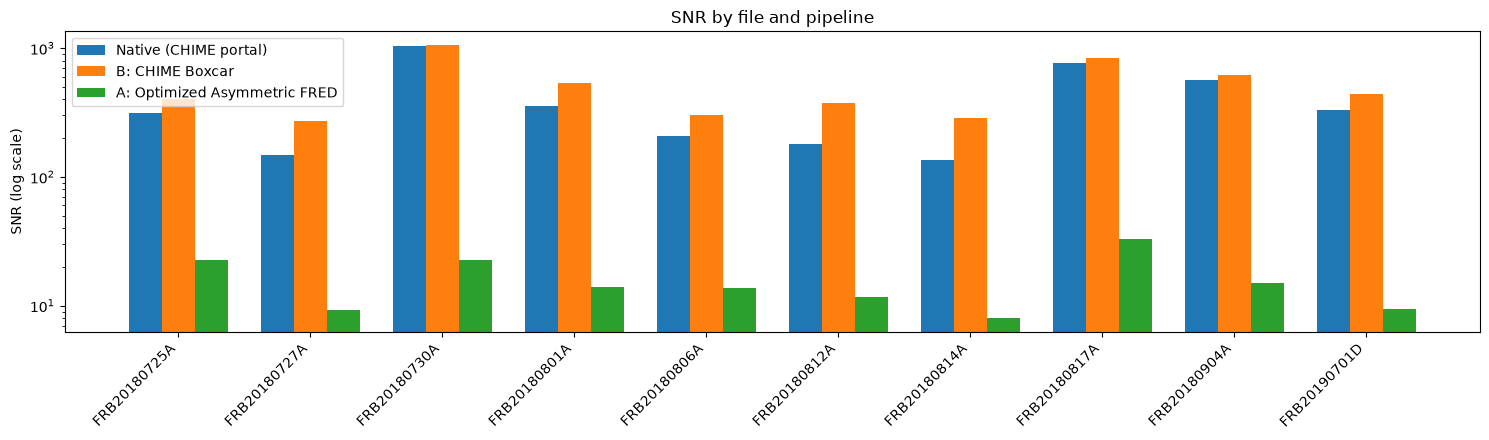

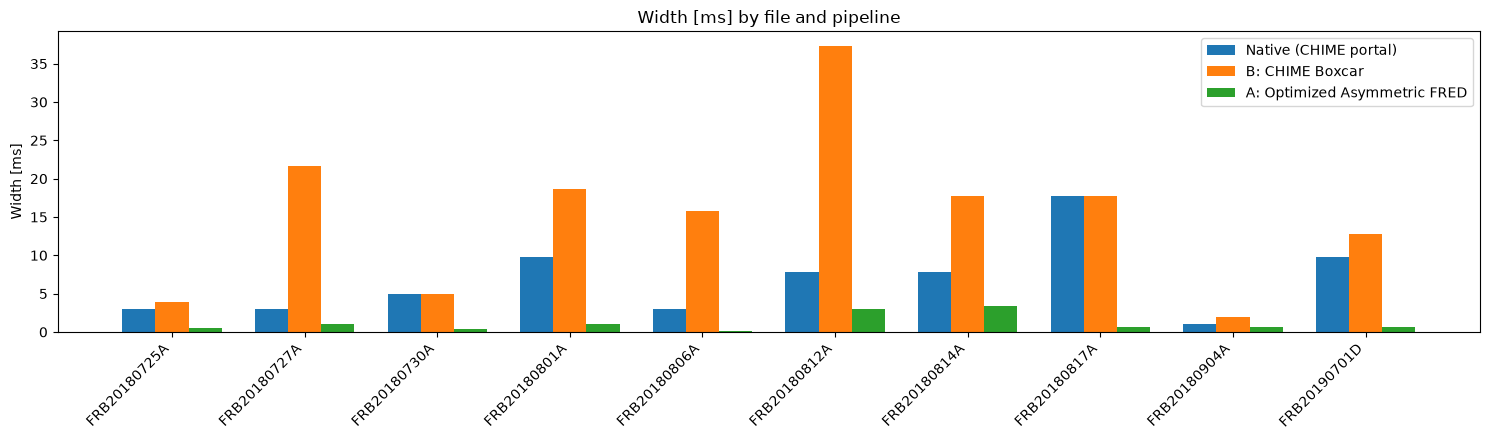

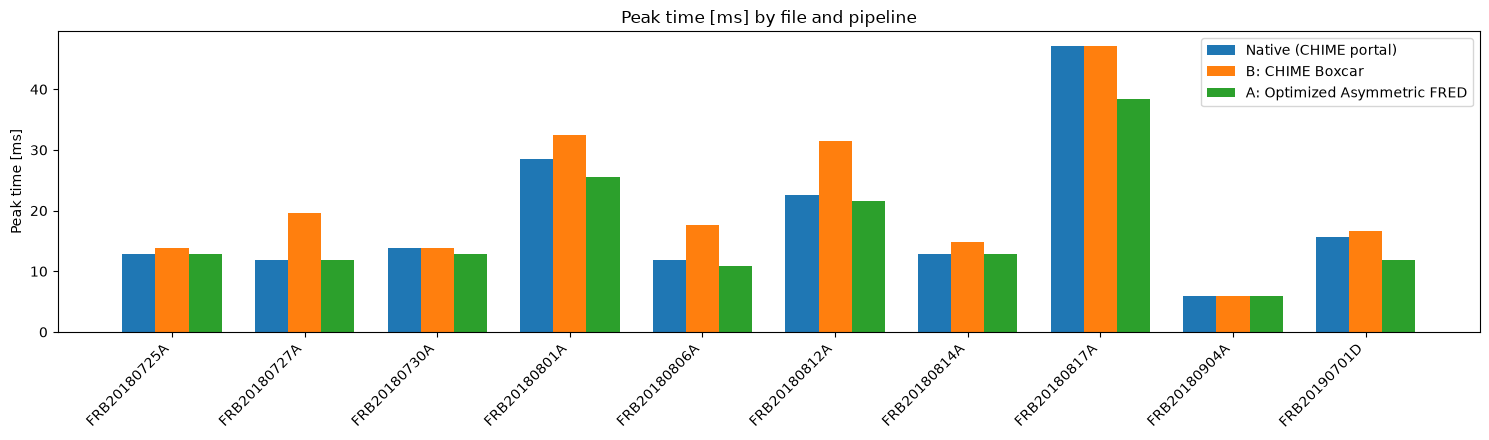

In [4]:
"""
CHIME multi-channel HDF5 pulse-detection pipeline
==================================================

This script implements the flowchart exactly as three branches:

  LEFT   : NATIVE CHIME WEB PORTAL
           -> reproduces CHIME/FRB Open Data "Tutorial 1"
              (https://chime-frb-open-data.github.io/waterfall/) verbatim,
              including its known weaknesses (no detrending, fixed 3x
              variance RFI cut, un-normalized amplitude).

  RIGHT  : YOUR SYSTEM
           Common front-end (steps 1-3) feeds into two competing
           back-ends:
             Pipeline B: CHIME Boxcar        (steps 4,5)
             Pipeline A: Optimized Asymmetric FRED (steps 4a,4b,5)

Every function is tagged with the flowchart box it implements, e.g.
"[STEP 2 - NATIVE]" or "[STEP 4a - PIPELINE A]", so you can map code
back to the diagram directly.

============================== ASSUMPTIONS =================================
The flowchart does not give numeric values for several "your system" boxes.
I picked the following defaults -- change them in the CONFIG block below,
do NOT edit function internals unless you tell me the underlying method
should change:

 1. Local window detrending (Step 1): implemented as a per-channel
    running-median subtraction. Window defaults to 100 ms, i.e. much
    wider than typical ms-scale FRB/pulsar pulses, so the slow drift is
    removed without eating the fast peak.
 2. Adaptive MAD RFI masking (Step 2): flags channels whose robust
    scatter (MAD) deviates from the median channel scatter by more than
    k=5 scaled-MADs (1.4826*MAD ~ sigma for a Gaussian). k is a CONFIG
    value.
 3. Frequency axis aggregation (Step 3): plain np.nansum over frequency,
    same operator as the native branch, just applied to cleaned data.
 4. FRED model (Step 4a): I used the standard "Gaussian rise convolved
    with one-sided exponential decay" pulse shape (an Exponentially
    Modified Gaussian / EMG), because that is the standard closed-form
    asymmetric FRED shape used for scattered radio pulses. sigma = rise
    width, tau = decay time. curve_fit extracts (A, t0, sigma, tau).
 5. Asymmetric FRED filter / template (Step 4b): the fitted EMG curve
    itself, energy-normalized (sum(template**2) = 1) so the correlation
    output is a true matched-filter statistic.
 6. Sliding Index Dot Product (Step 5, Pipeline A): scipy.signal.correlate
    of the time series against the template, followed by an explicit
    index correction for the template's own internal peak offset
    (zero-padding + relabeling), so the reported peak sample is the
    physical peak, not shifted by the asymmetric kernel's group delay.
 7. Noise / SNR normalization: Pipeline B keeps the native tutorial's
    convention (SNR = raw convolved peak amplitude, no explicit noise
    division -- this IS the "rigid, tail-dragged" bias the chart
    describes). Pipeline A divides the matched-filter peak by a robust
    off-pulse noise estimate (1.4826 * MAD of an off-pulse region of the
    time series), giving a true statistical significance, per the box
    label "Maximum significance statistical SNR".

If any of these 7 choices should be different, tell me which one and
what you want instead -- I will not change them speculatively.
==============================================================================
"""

import glob
import os

import h5py
import numpy as np
import pandas as pd
import scipy.signal
from scipy.ndimage import median_filter
from scipy.optimize import curve_fit
from scipy.special import erfc
import matplotlib.pyplot as plt

# ============================================================================
# CONFIG -- edit these, not the function bodies
# ============================================================================
DATA_DIR = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images"  # your waterfall .h5 folder
FILE_PATTERN = "*.h5"        # glob pattern for CHIME waterfall files

RFI_VAR_FACTOR = 3           # native branch, fixed (matches CHIME tutorial)
MAD_K = 5.0                  # your-system adaptive MAD threshold (in scaled-MAD units)
DETREND_WINDOW_MS = 100.0    # your-system local detrending window

BOXCAR_MIN_WIDTH = 1         # samples, native + pipeline B
BOXCAR_MAX_WIDTH = 128       # samples, native + pipeline B

FRED_FIT_WINDOW = 256        # samples on either side of peak used for curve_fit


# ============================================================================
# BLOCK 0  --  [ RAW MULTI-CHANNEL HDF5 DATA ]
# ============================================================================
def load_hdf5(file_name):
    """Read one CHIME/FRB waterfall .h5 file and unpack the arrays used
    downstream by every branch (mirrors the tutorial's "Read hdf5 files"
    section exactly)."""
    with h5py.File(file_name, "r") as f:
        data = f["frb"]
        eventname = data.attrs["tns_name"].decode() if "tns_name" in data.attrs else os.path.basename(file_name)
        wfall = data["wfall"][:].astype(float)
        spec = data["spec"][:].astype(float)
        plot_time = data["plot_time"][:]
        plot_freq = data["plot_freq"][:]
        dm = data.attrs["dm"][()] if "dm" in data.attrs else None

    dt = float(np.median(np.diff(plot_time)))  # ms between time samples
    return {
        "eventname": eventname,
        "wfall": wfall,
        "spec": spec,
        "plot_time": plot_time,
        "plot_freq": plot_freq,
        "dt": dt,
        "dm": dm,
        "file_name": file_name,
    }


# ============================================================================
# LEFT BRANCH -- [ NATIVE CHIME WEB PORTAL ]  (= CHIME/FRB Tutorial 1, verbatim)
# ============================================================================
def native_rfi_mask(wfall, spec, rfi_masking_var_factor=RFI_VAR_FACTOR):
    """[STEP 2 - NATIVE] Fixed statistical filter: flag channels whose
    variance exceeds `rfi_masking_var_factor`x the mean channel variance,
    plus an IQR outlier cut on `spec`. Ported directly from the tutorial."""
    q1 = np.nanquantile(spec, 0.25)
    q3 = np.nanquantile(spec, 0.75)
    iqr = q3 - q1

    channel_variance = np.nanvar(wfall, axis=1)
    mean_channel_variance = np.nanmean(channel_variance)

    with np.errstate(invalid="ignore"):
        rfi_mask = (
            (channel_variance > rfi_masking_var_factor * mean_channel_variance)
            | (spec[::-1] < q1 - 1.5 * iqr)
            | (spec[::-1] > q3 + 1.5 * iqr)
        )
    wfall = wfall.copy()
    wfall[rfi_mask, ...] = np.nan
    return wfall, rfi_mask


def native_frequency_integration(wfall):
    """[STEP 3 - NATIVE] Un-detrended frequency collapse via np.nansum."""
    return np.nansum(wfall, axis=0)


def boxcar_kernel(width):
    """[STEP 5 - NATIVE/PIPELINE B] Flat top-hat kernel, energy-scaled by 1/sqrt(W)."""
    width = int(round(width))
    return np.ones(width, dtype="float64") / np.sqrt(width)


def iterative_boxcar_search(ts, min_width=BOXCAR_MIN_WIDTH, max_width=BOXCAR_MAX_WIDTH):
    """[STEP 4 - NATIVE/PIPELINE B] Iterative integer window loop +
    [STEP 6 - NATIVE / STEP 5 - PIPELINE B] symmetric sliding convolution
    via scipy.signal.convolve. Returns (peak_sample, width, raw_snr)."""
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))

    snrs = np.empty(len(widths), dtype=float)
    peaks = np.empty(len(widths), dtype=int)
    for i, w in enumerate(widths):
        convolved = scipy.signal.convolve(ts, boxcar_kernel(w), mode="same")
        peaks[i] = np.nanargmax(convolved)
        snrs[i] = convolved[peaks[i]]

    best_idx = np.nanargmax(snrs)
    return peaks[best_idx], widths[best_idx], snrs[best_idx]


def run_native_pipeline(file_name):
    """Runs the full LEFT branch end to end and returns raw, un-normalized results."""
    d = load_hdf5(file_name)
    wfall_masked, _ = native_rfi_mask(d["wfall"], d["spec"])
    ts = native_frequency_integration(wfall_masked)
    peak, width, snr = iterative_boxcar_search(ts)
    return {
        "file_name": d["file_name"],
        "eventname": d["eventname"],
        "pipeline": "Native (CHIME portal)",
        "peak_sample": peak,
        "peak_time_ms": peak * d["dt"],
        "width_samples": width,
        "width_ms": width * d["dt"],
        "snr": snr,
    }


# ============================================================================
# RIGHT BRANCH -- [ YOUR SYSTEM: COMMON FRONT-END DEFRAGGING ]
# ============================================================================
def local_window_detrend(wfall, dt, window_ms=DETREND_WINDOW_MS):
    """[STEP 1 - YOUR SYSTEM] Local window detrending: per-channel running
    median subtraction removes slow drift while a fast (ms-scale) peak
    passes through untouched, since the window is much wider than the pulse."""
    window_samples = max(3, int(round(window_ms / dt)))
    if window_samples % 2 == 0:
        window_samples += 1  # median_filter wants an odd kernel
    trend = median_filter(wfall, size=(1, window_samples), mode="nearest")
    return wfall - trend


def adaptive_mad_mask(wfall, k=MAD_K):
    """[STEP 2 - YOUR SYSTEM] Adaptive MAD RFI masking: non-parametric,
    median/MAD based channel flagging (robust to the very spikes that
    break the native branch's mean/variance filter)."""
    channel_scatter = np.nanstd(wfall, axis=1)
    med = np.nanmedian(channel_scatter)
    mad = np.nanmedian(np.abs(channel_scatter - med))
    scaled_mad = 1.4826 * mad if mad > 0 else np.nanstd(channel_scatter)

    with np.errstate(invalid="ignore"):
        mask = np.abs(channel_scatter - med) > k * scaled_mad

    wfall = wfall.copy()
    wfall[mask, ...] = np.nan
    return wfall, mask


def aggregate_frequency(wfall_clean):
    """[STEP 3 - YOUR SYSTEM] Frequency axis aggregation on cleaned data."""
    return np.nansum(wfall_clean, axis=0)


def common_front_end(d):
    """Runs steps 1-3 of the right branch and returns the cleaned time series."""
    detrended = local_window_detrend(d["wfall"], d["dt"])
    masked, mask = adaptive_mad_mask(detrended)
    ts = aggregate_frequency(masked)
    return ts, mask


# ----------------------------------------------------------------------------
# PIPELINE B -- [ CHIME BOXCAR ]  (steps 4, 5 -- reuses the symmetric boxcar
# machinery from the native branch, run on the cleaned time series instead)
# ----------------------------------------------------------------------------
def run_pipeline_B(ts, dt):
    peak, width, raw_snr = iterative_boxcar_search(ts)
    return {
        "pipeline": "B: CHIME Boxcar",
        "peak_sample": peak,
        "peak_time_ms": peak * dt,
        "width_samples": width,
        "width_ms": width * dt,
        "snr": raw_snr,  # [ASSUMPTION 7] intentionally un-normalized, matches "rigid approximated SNR"
    }


# ----------------------------------------------------------------------------
# PIPELINE A -- [ OPTIMIZED ASYMMETRIC FRED ]  (steps 4a, 4b, 5)
# ----------------------------------------------------------------------------
def fred_model(t, A, t0, sigma, tau):
    """[STEP 4a - PIPELINE A] Asymmetric FRED pulse shape: a Gaussian rise
    convolved with a one-sided exponential decay (Exponentially Modified
    Gaussian). sigma = rise width, tau = decay time constant."""
    tau = max(tau, 1e-6)
    sigma = max(sigma, 1e-6)
    exponent = np.clip((sigma ** 2) / (2 * tau ** 2) - (t - t0) / tau, -700, 700)
    z = (sigma / tau - (t - t0) / sigma) / np.sqrt(2)
    return 0.5 * A * np.exp(exponent) * erfc(z)


def fit_fred(ts, dt, window=FRED_FIT_WINDOW):
    """[STEP 4a - PIPELINE A] Non-linear chi-squared model fit via
    scipy.optimize.curve_fit to extract the true physical width (sigma)
    and decay tau of the pulse."""
    peak_guess = int(np.nanargmax(ts))
    lo = max(0, peak_guess - window)
    hi = min(len(ts), peak_guess + window)

    t_idx = np.arange(lo, hi)
    y = ts[lo:hi]
    y = np.nan_to_num(y, nan=0.0)

    A0 = np.nanmax(y)
    t0_0 = peak_guess
    sigma0 = 3.0
    tau0 = 5.0
    p0 = [A0, t0_0, sigma0, tau0]

    try:
        popt, _ = curve_fit(fred_model, t_idx, y, p0=p0, maxfev=10000)
    except RuntimeError:
        # fall back to the initial guess if the fit fails to converge
        popt = p0

    A, t0, sigma, tau = popt
    return {"A": A, "t0": t0, "sigma": abs(sigma), "tau": abs(tau)}


def build_fred_template(params, n_samples=None):
    """[STEP 4b - PIPELINE A] Asymmetric FRED filter: builds an
    energy-normalized template from the fitted decay morphology so that
    the correlation output below is a true matched-filter statistic."""
    sigma, tau = params["sigma"], params["tau"]
    if n_samples is None:
        n_samples = int(round(10 * (sigma + tau))) + 1
        n_samples = max(n_samples, 11)

    t_local = np.arange(n_samples)
    center = n_samples // 2
    template = fred_model(t_local, 1.0, center, sigma, tau)

    norm = np.sqrt(np.sum(template ** 2))
    if norm > 0:
        template = template / norm
    return template


def sliding_dot_product(ts, template):
    """[STEP 5 - PIPELINE A] Sliding Index Dot Product: cross-correlates
    the cleaned time series against the asymmetric template and corrects
    the reported index for the template's own internal peak offset
    (zero-padding), so the peak lock is on the true physical peak rather
    than dragged by the kernel's asymmetric group delay."""
    n_template = len(template)
    peak_offset_in_template = int(np.argmax(template))

    corr = scipy.signal.correlate(ts, template, mode="full")
    lags = np.arange(-(n_template - 1), len(ts))
    corrected_index = lags + peak_offset_in_template

    valid = (corrected_index >= 0) & (corrected_index < len(ts))
    corr_valid = corr[valid]
    idx_valid = corrected_index[valid]

    best = int(np.nanargmax(corr_valid))
    return int(idx_valid[best]), float(corr_valid[best])


def robust_noise_sigma(ts, exclude_radius=200):
    """Off-pulse robust noise estimate (1.4826 * MAD), excluding a window
    around the global peak, used to turn the matched-filter amplitude into
    a true statistical significance for Pipeline A."""
    peak = int(np.nanargmax(ts))
    lo = max(0, peak - exclude_radius)
    hi = min(len(ts), peak + exclude_radius)
    off_pulse = np.concatenate([ts[:lo], ts[hi:]])
    off_pulse = off_pulse[~np.isnan(off_pulse)]
    if len(off_pulse) < 10:
        off_pulse = ts[~np.isnan(ts)]
    med = np.nanmedian(off_pulse)
    mad = np.nanmedian(np.abs(off_pulse - med))
    return 1.4826 * mad if mad > 0 else np.nanstd(off_pulse)


def run_pipeline_A(ts, dt):
    fred_params = fit_fred(ts, dt)
    template = build_fred_template(fred_params)
    peak_sample, matched_filter_amp = sliding_dot_product(ts, template)
    noise_sigma = robust_noise_sigma(ts)
    snr = matched_filter_amp / noise_sigma if noise_sigma > 0 else np.nan

    return {
        "pipeline": "A: Optimized Asymmetric FRED",
        "peak_sample": peak_sample,
        "peak_time_ms": peak_sample * dt,
        "width_samples": fred_params["sigma"],
        "width_ms": fred_params["sigma"] * dt,
        "decay_tau_ms": fred_params["tau"] * dt,
        "snr": snr,  # [ASSUMPTION 7] normalized by robust off-pulse noise
    }


def run_your_system(file_name):
    """Runs the full RIGHT branch: common front-end -> Pipeline B and Pipeline A."""
    d = load_hdf5(file_name)
    ts, _mask = common_front_end(d)

    result_B = run_pipeline_B(ts, d["dt"])
    result_A = run_pipeline_A(ts, d["dt"])

    for r in (result_B, result_A):
        r["file_name"] = d["file_name"]
        r["eventname"] = d["eventname"]

    return result_B, result_A


# ============================================================================
# BATCH / DIRECTORY PROCESSING
# ============================================================================
def process_directory(data_dir=DATA_DIR, pattern=FILE_PATTERN):
    """Opens every matching .h5 file in `data_dir`, runs all three
    pipelines (Native, B, A) on each, and returns one tidy DataFrame."""
    file_list = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not file_list:
        raise FileNotFoundError(
            f"No files matching '{pattern}' found in '{data_dir}'. "
            f"Set DATA_DIR / FILE_PATTERN at the top of the script."
        )

    rows = []
    for fname in file_list:
        try:
            rows.append(run_native_pipeline(fname))
            result_B, result_A = run_your_system(fname)
            rows.append(result_B)
            rows.append(result_A)
        except Exception as exc:
            print(f"[WARN] skipped '{fname}': {exc}")

    return pd.DataFrame(rows)


# ============================================================================
# PLOTS -- SNR, width, and peak per file, for every pipeline
# ============================================================================
def plot_results(df, save_dir=None):
    """Grouped bar charts comparing Native / Pipeline B / Pipeline A for
    SNR, width (ms), and peak time (ms), one group of bars per file.

    NOTE: Native/B report raw un-normalized boxcar amplitude ("rigid
    approximated SNR"); Pipeline A reports a noise-normalized detection
    significance ("maximum significance statistical SNR"). These are
    different physical quantities by design (see script header,
    assumption 7) and can differ by 1-2 orders of magnitude for the same
    burst. The SNR panel therefore uses a log y-axis so all three stay
    visible on one chart instead of A's bars disappearing next to B's."""
    metrics = [
        ("snr", "SNR", True),           # (column, label, use_log_scale)
        ("width_ms", "Width [ms]", False),
        ("peak_time_ms", "Peak time [ms]", False),
    ]
    events = sorted(df["eventname"].unique())
    pipelines = ["Native (CHIME portal)", "B: CHIME Boxcar", "A: Optimized Asymmetric FRED"]

    x = np.arange(len(events))
    bar_width = 0.25

    for metric_col, metric_label, use_log in metrics:
        fig, ax = plt.subplots(figsize=(max(6, len(events) * 1.5), 4.5))
        for i, pipeline in enumerate(pipelines):
            sub = df[df["pipeline"] == pipeline].set_index("eventname")
            values = [sub[metric_col].get(ev, np.nan) for ev in events]
            ax.bar(x + (i - 1) * bar_width, values, width=bar_width, label=pipeline)

        ax.set_xticks(x)
        ax.set_xticklabels(events, rotation=45, ha="right")
        ax.set_ylabel(metric_label + (" (log scale)" if use_log else ""))
        if use_log:
            ax.set_yscale("log")
        ax.set_title(f"{metric_label} by file and pipeline")
        ax.legend()
        fig.tight_layout()

        if save_dir:
            fig.savefig(os.path.join(save_dir, f"{metric_col}_comparison.png"), dpi=150)
        plt.show()


# ============================================================================
# ENTRY POINT
# ============================================================================
if __name__ == "__main__":
    results_df = process_directory(DATA_DIR, FILE_PATTERN)
    print(results_df[["eventname", "pipeline", "snr", "width_ms", "peak_time_ms"]])
    plot_results(results_df, save_dir=DATA_DIR)


/tmp/ipykernel_6589/2429445842.py:135: RuntimeWarning: Degrees of freedom <= 0 for slice.
  channel_variance = np.nanvar(wfall, axis=1)
/mnt/d/GCS(trial)/data/chime-frb-open-data-master/venv_chime_frb/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_6589/2429445842.py:300: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(fred_model, t_idx, y, p0=p0, maxfev=10000)


       eventname                      pipeline          snr   width_ms  \
0   FRB20180725A         Native (CHIME portal)   311.775313   2.949120   
1   FRB20180725A               B: CHIME Boxcar   400.337608   3.932160   
2   FRB20180725A  A: Optimized Asymmetric FRED   439.013642   0.519562   
3   FRB20180727A         Native (CHIME portal)   148.256974   2.949120   
4   FRB20180727A               B: CHIME Boxcar   272.379619  21.626880   
5   FRB20180727A  A: Optimized Asymmetric FRED   291.527753   1.025330   
6   FRB20180730A         Native (CHIME portal)  1039.461321   4.915200   
7   FRB20180730A               B: CHIME Boxcar  1056.712262   4.915200   
8   FRB20180730A  A: Optimized Asymmetric FRED  1155.589766   0.433369   
9   FRB20180801A         Native (CHIME portal)   354.825351   9.830400   
10  FRB20180801A               B: CHIME Boxcar   537.238696  18.677760   
11  FRB20180801A  A: Optimized Asymmetric FRED   594.564765   1.035810   
12  FRB20180806A         Native (CHIME

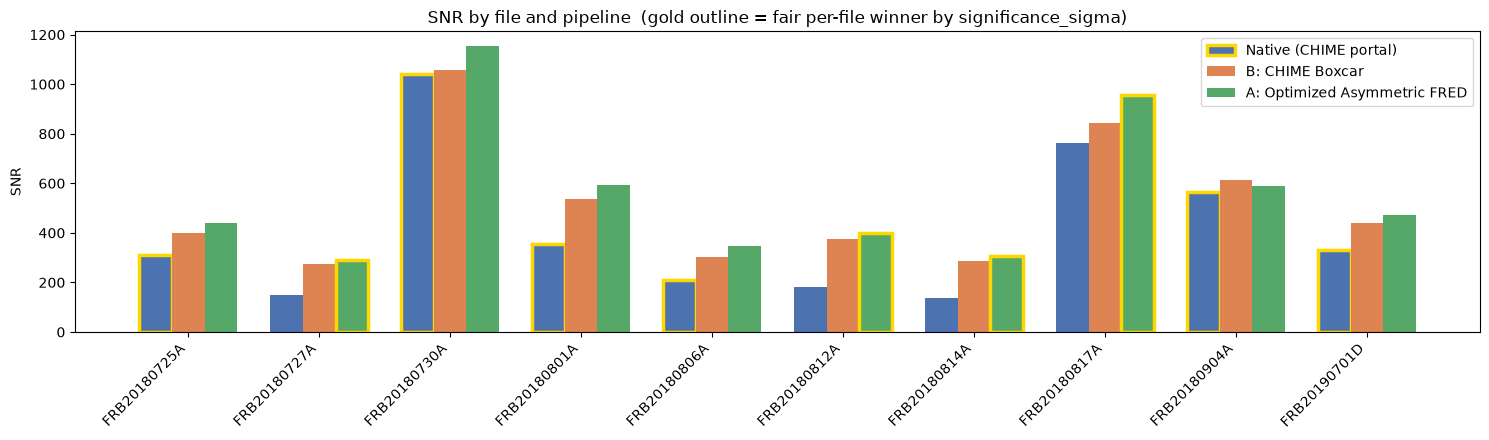

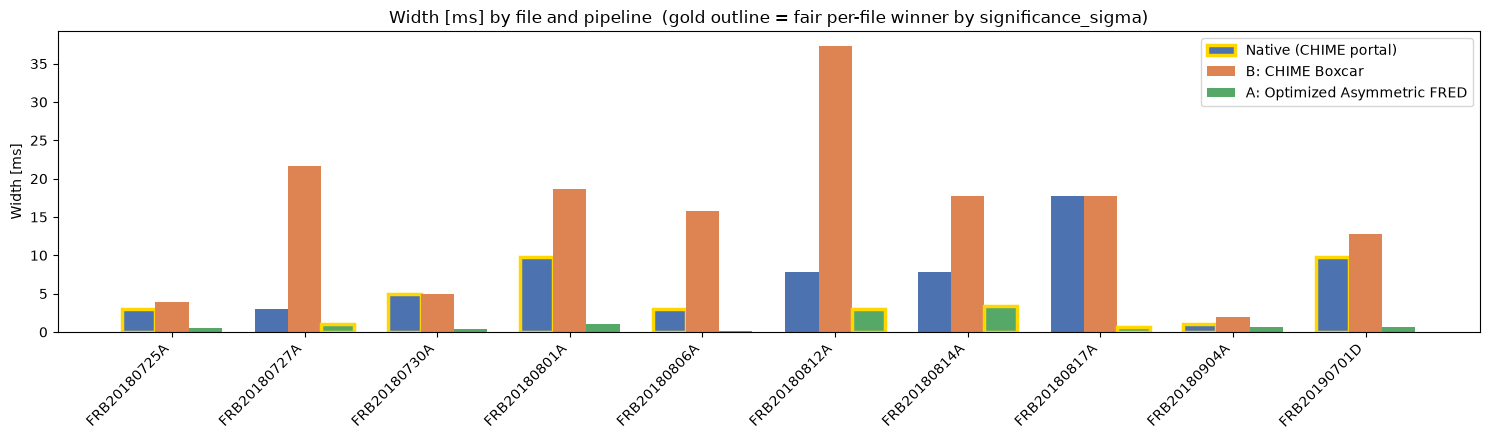

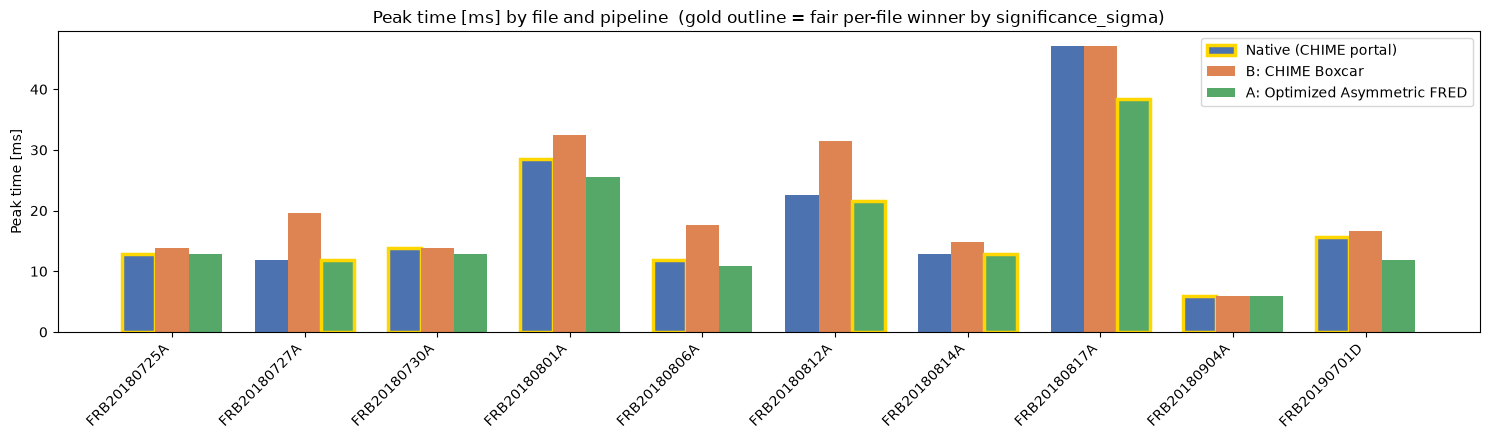

In [1]:
"""
CHIME multi-channel HDF5 pulse-detection pipeline
==================================================

This script implements the flowchart exactly as three branches:

  LEFT   : NATIVE CHIME WEB PORTAL
           -> reproduces CHIME/FRB Open Data "Tutorial 1"
              (https://chime-frb-open-data.github.io/waterfall/) verbatim,
              including its known weaknesses (no detrending, fixed 3x
              variance RFI cut, un-normalized amplitude).

  RIGHT  : YOUR SYSTEM
           Common front-end (steps 1-3) feeds into two competing
           back-ends:
             Pipeline B: CHIME Boxcar        (steps 4,5)
             Pipeline A: Optimized Asymmetric FRED (steps 4a,4b,5)

Every function is tagged with the flowchart box it implements, e.g.
"[STEP 2 - NATIVE]" or "[STEP 4a - PIPELINE A]", so you can map code
back to the diagram directly.

============================== ASSUMPTIONS =================================
The flowchart does not give numeric values for several "your system" boxes.
I picked the following defaults -- change them in the CONFIG block below,
do NOT edit function internals unless you tell me the underlying method
should change:

 1. Local window detrending (Step 1): implemented as a per-channel
    running-median subtraction. Window defaults to 100 ms, i.e. much
    wider than typical ms-scale FRB/pulsar pulses, so the slow drift is
    removed without eating the fast peak.
 2. Adaptive MAD RFI masking (Step 2): flags channels whose robust
    scatter (MAD) deviates from the median channel scatter by more than
    k=5 scaled-MADs (1.4826*MAD ~ sigma for a Gaussian). k is a CONFIG
    value.
 3. Frequency axis aggregation (Step 3): plain np.nansum over frequency,
    same operator as the native branch, just applied to cleaned data.
 4. FRED model (Step 4a): I used the standard "Gaussian rise convolved
    with one-sided exponential decay" pulse shape (an Exponentially
    Modified Gaussian / EMG), because that is the standard closed-form
    asymmetric FRED shape used for scattered radio pulses. sigma = rise
    width, tau = decay time. curve_fit extracts (A, t0, sigma, tau).
 5. Asymmetric FRED filter / template (Step 4b): the fitted EMG curve
    itself, energy-normalized (sum(template**2) = 1) so the correlation
    output is a true matched-filter statistic.
 6. Sliding Index Dot Product (Step 5, Pipeline A): scipy.signal.correlate
    of the time series against the template, followed by an explicit
    index correction for the template's own internal peak offset
    (zero-padding + relabeling), so the reported peak sample is the
    physical peak, not shifted by the asymmetric kernel's group delay.
 7. [UPDATED per user request, 2024] Noise / SNR normalization: all three
    pipelines' main "snr" field is now the raw unit-energy-normalized
    template dot product (boxcar for Native/B, asymmetric FRED for A)
    against the flux time series -- same units, directly comparable on
    one linear-axis chart. Each pipeline ALSO reports a separate
    "significance_sigma" field (that same peak divided by a robust
    off-pulse noise estimate, 1.4826 * MAD), used only to pick a fair
    per-file "winner" for plot highlighting, since a wider boxcar can
    inflate raw snr without being a genuinely more significant detection.

If any of these 7 choices should be different, tell me which one and
what you want instead -- I will not change them speculatively.
==============================================================================
"""

import glob
import os

import h5py
import numpy as np
import pandas as pd
import scipy.signal
from scipy.ndimage import median_filter
from scipy.optimize import curve_fit
from scipy.special import erfc
import matplotlib.pyplot as plt

# ============================================================================
# CONFIG -- edit these, not the function bodies
# ============================================================================
DATA_DIR = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images"  # your waterfall .h5 folder
FILE_PATTERN = "*.h5"        # glob pattern for CHIME waterfall files

RFI_VAR_FACTOR = 3           # native branch, fixed (matches CHIME tutorial)
MAD_K = 5.0                  # your-system adaptive MAD threshold (in scaled-MAD units)
DETREND_WINDOW_MS = 100.0    # your-system local detrending window

BOXCAR_MIN_WIDTH = 1         # samples, native + pipeline B
BOXCAR_MAX_WIDTH = 128       # samples, native + pipeline B

FRED_FIT_WINDOW = 256        # samples on either side of peak used for curve_fit


# ============================================================================
# BLOCK 0  --  [ RAW MULTI-CHANNEL HDF5 DATA ]
# ============================================================================
def load_hdf5(file_name):
    """Read one CHIME/FRB waterfall .h5 file and unpack the arrays used
    downstream by every branch (mirrors the tutorial's "Read hdf5 files"
    section exactly)."""
    with h5py.File(file_name, "r") as f:
        data = f["frb"]
        eventname = data.attrs["tns_name"].decode() if "tns_name" in data.attrs else os.path.basename(file_name)
        wfall = data["wfall"][:].astype(float)
        spec = data["spec"][:].astype(float)
        plot_time = data["plot_time"][:]
        plot_freq = data["plot_freq"][:]
        dm = data.attrs["dm"][()] if "dm" in data.attrs else None

    dt = float(np.median(np.diff(plot_time)))  # ms between time samples
    return {
        "eventname": eventname,
        "wfall": wfall,
        "spec": spec,
        "plot_time": plot_time,
        "plot_freq": plot_freq,
        "dt": dt,
        "dm": dm,
        "file_name": file_name,
    }


# ============================================================================
# LEFT BRANCH -- [ NATIVE CHIME WEB PORTAL ]  (= CHIME/FRB Tutorial 1, verbatim)
# ============================================================================
def native_rfi_mask(wfall, spec, rfi_masking_var_factor=RFI_VAR_FACTOR):
    """[STEP 2 - NATIVE] Fixed statistical filter: flag channels whose
    variance exceeds `rfi_masking_var_factor`x the mean channel variance,
    plus an IQR outlier cut on `spec`. Ported directly from the tutorial."""
    q1 = np.nanquantile(spec, 0.25)
    q3 = np.nanquantile(spec, 0.75)
    iqr = q3 - q1

    channel_variance = np.nanvar(wfall, axis=1)
    mean_channel_variance = np.nanmean(channel_variance)

    with np.errstate(invalid="ignore"):
        rfi_mask = (
            (channel_variance > rfi_masking_var_factor * mean_channel_variance)
            | (spec[::-1] < q1 - 1.5 * iqr)
            | (spec[::-1] > q3 + 1.5 * iqr)
        )
    wfall = wfall.copy()
    wfall[rfi_mask, ...] = np.nan
    return wfall, rfi_mask


def native_frequency_integration(wfall):
    """[STEP 3 - NATIVE] Un-detrended frequency collapse via np.nansum."""
    return np.nansum(wfall, axis=0)


def boxcar_kernel(width):
    """[STEP 5 - NATIVE/PIPELINE B] Flat top-hat kernel, energy-scaled by 1/sqrt(W)."""
    width = int(round(width))
    return np.ones(width, dtype="float64") / np.sqrt(width)


def iterative_boxcar_search(ts, min_width=BOXCAR_MIN_WIDTH, max_width=BOXCAR_MAX_WIDTH):
    """[STEP 4 - NATIVE/PIPELINE B] Iterative integer window loop +
    [STEP 6 - NATIVE / STEP 5 - PIPELINE B] symmetric sliding convolution
    via scipy.signal.convolve. Returns (peak_sample, width, raw_snr)."""
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))

    snrs = np.empty(len(widths), dtype=float)
    peaks = np.empty(len(widths), dtype=int)
    for i, w in enumerate(widths):
        convolved = scipy.signal.convolve(ts, boxcar_kernel(w), mode="same")
        peaks[i] = np.nanargmax(convolved)
        snrs[i] = convolved[peaks[i]]

    best_idx = np.nanargmax(snrs)
    return peaks[best_idx], widths[best_idx], snrs[best_idx]


def run_native_pipeline(file_name):
    """Runs the full LEFT branch end to end and returns raw, un-normalized results."""
    d = load_hdf5(file_name)
    wfall_masked, _ = native_rfi_mask(d["wfall"], d["spec"])
    ts = native_frequency_integration(wfall_masked)
    peak, width, snr = iterative_boxcar_search(ts)
    noise = robust_noise_sigma(ts)
    return {
        "file_name": d["file_name"],
        "eventname": d["eventname"],
        "pipeline": "Native (CHIME portal)",
        "peak_sample": peak,
        "peak_time_ms": peak * d["dt"],
        "width_samples": width,
        "width_ms": width * d["dt"],
        "snr": snr,
        # noise-normalized significance, used ONLY to pick a fair "winner" for
        # plot highlighting -- not a replacement for the raw "snr" above.
        "significance_sigma": snr / noise if noise > 0 else np.nan,
    }


# ============================================================================
# RIGHT BRANCH -- [ YOUR SYSTEM: COMMON FRONT-END DEFRAGGING ]
# ============================================================================
def local_window_detrend(wfall, dt, window_ms=DETREND_WINDOW_MS):
    """[STEP 1 - YOUR SYSTEM] Local window detrending: per-channel running
    median subtraction removes slow drift while a fast (ms-scale) peak
    passes through untouched, since the window is much wider than the pulse."""
    window_samples = max(3, int(round(window_ms / dt)))
    if window_samples % 2 == 0:
        window_samples += 1  # median_filter wants an odd kernel
    trend = median_filter(wfall, size=(1, window_samples), mode="nearest")
    return wfall - trend


def adaptive_mad_mask(wfall, k=MAD_K):
    """[STEP 2 - YOUR SYSTEM] Adaptive MAD RFI masking: non-parametric,
    median/MAD based channel flagging (robust to the very spikes that
    break the native branch's mean/variance filter)."""
    channel_scatter = np.nanstd(wfall, axis=1)
    med = np.nanmedian(channel_scatter)
    mad = np.nanmedian(np.abs(channel_scatter - med))
    scaled_mad = 1.4826 * mad if mad > 0 else np.nanstd(channel_scatter)

    with np.errstate(invalid="ignore"):
        mask = np.abs(channel_scatter - med) > k * scaled_mad

    wfall = wfall.copy()
    wfall[mask, ...] = np.nan
    return wfall, mask


def aggregate_frequency(wfall_clean):
    """[STEP 3 - YOUR SYSTEM] Frequency axis aggregation on cleaned data."""
    return np.nansum(wfall_clean, axis=0)


def common_front_end(d):
    """Runs steps 1-3 of the right branch and returns the cleaned time series."""
    detrended = local_window_detrend(d["wfall"], d["dt"])
    masked, mask = adaptive_mad_mask(detrended)
    ts = aggregate_frequency(masked)
    return ts, mask


# ----------------------------------------------------------------------------
# PIPELINE B -- [ CHIME BOXCAR ]  (steps 4, 5 -- reuses the symmetric boxcar
# machinery from the native branch, run on the cleaned time series instead)
# ----------------------------------------------------------------------------
def run_pipeline_B(ts, dt):
    peak, width, raw_snr = iterative_boxcar_search(ts)
    noise = robust_noise_sigma(ts)
    return {
        "pipeline": "B: CHIME Boxcar",
        "peak_sample": peak,
        "peak_time_ms": peak * dt,
        "width_samples": width,
        "width_ms": width * dt,
        # [UPDATED per user request] raw unit-energy-normalized boxcar
        # amplitude -- now directly comparable in units to Pipeline A's snr.
        "snr": raw_snr,
        # noise-normalized significance, used ONLY to pick a fair "winner"
        # for plot highlighting -- not a replacement for the raw "snr" above.
        "significance_sigma": raw_snr / noise if noise > 0 else np.nan,
    }


# ----------------------------------------------------------------------------
# PIPELINE A -- [ OPTIMIZED ASYMMETRIC FRED ]  (steps 4a, 4b, 5)
# ----------------------------------------------------------------------------
def fred_model(t, A, t0, sigma, tau):
    """[STEP 4a - PIPELINE A] Asymmetric FRED pulse shape: a Gaussian rise
    convolved with a one-sided exponential decay (Exponentially Modified
    Gaussian). sigma = rise width, tau = decay time constant."""
    tau = max(tau, 1e-6)
    sigma = max(sigma, 1e-6)
    exponent = np.clip((sigma ** 2) / (2 * tau ** 2) - (t - t0) / tau, -700, 700)
    z = (sigma / tau - (t - t0) / sigma) / np.sqrt(2)
    return 0.5 * A * np.exp(exponent) * erfc(z)


def fit_fred(ts, dt, window=FRED_FIT_WINDOW):
    """[STEP 4a - PIPELINE A] Non-linear chi-squared model fit via
    scipy.optimize.curve_fit to extract the true physical width (sigma)
    and decay tau of the pulse."""
    peak_guess = int(np.nanargmax(ts))
    lo = max(0, peak_guess - window)
    hi = min(len(ts), peak_guess + window)

    t_idx = np.arange(lo, hi)
    y = ts[lo:hi]
    y = np.nan_to_num(y, nan=0.0)

    A0 = np.nanmax(y)
    t0_0 = peak_guess
    sigma0 = 3.0
    tau0 = 5.0
    p0 = [A0, t0_0, sigma0, tau0]

    try:
        popt, _ = curve_fit(fred_model, t_idx, y, p0=p0, maxfev=10000)
    except RuntimeError:
        # fall back to the initial guess if the fit fails to converge
        popt = p0

    A, t0, sigma, tau = popt
    return {"A": A, "t0": t0, "sigma": abs(sigma), "tau": abs(tau)}


def build_fred_template(params, n_samples=None):
    """[STEP 4b - PIPELINE A] Asymmetric FRED filter: builds an
    energy-normalized template from the fitted decay morphology so that
    the correlation output below is a true matched-filter statistic."""
    sigma, tau = params["sigma"], params["tau"]
    if n_samples is None:
        n_samples = int(round(10 * (sigma + tau))) + 1
        n_samples = max(n_samples, 11)

    t_local = np.arange(n_samples)
    center = n_samples // 2
    template = fred_model(t_local, 1.0, center, sigma, tau)

    norm = np.sqrt(np.sum(template ** 2))
    if norm > 0:
        template = template / norm
    return template


def sliding_dot_product(ts, template):
    """[STEP 5 - PIPELINE A] Sliding Index Dot Product: cross-correlates
    the cleaned time series against the asymmetric template and corrects
    the reported index for the template's own internal peak offset
    (zero-padding), so the peak lock is on the true physical peak rather
    than dragged by the kernel's asymmetric group delay."""
    n_template = len(template)
    peak_offset_in_template = int(np.argmax(template))

    corr = scipy.signal.correlate(ts, template, mode="full")
    lags = np.arange(-(n_template - 1), len(ts))
    corrected_index = lags + peak_offset_in_template

    valid = (corrected_index >= 0) & (corrected_index < len(ts))
    corr_valid = corr[valid]
    idx_valid = corrected_index[valid]

    best = int(np.nanargmax(corr_valid))
    return int(idx_valid[best]), float(corr_valid[best])


def robust_noise_sigma(ts, exclude_radius=200):
    """Off-pulse robust noise estimate (1.4826 * MAD), excluding a window
    around the global peak, used to turn the matched-filter amplitude into
    a true statistical significance for Pipeline A."""
    peak = int(np.nanargmax(ts))
    lo = max(0, peak - exclude_radius)
    hi = min(len(ts), peak + exclude_radius)
    off_pulse = np.concatenate([ts[:lo], ts[hi:]])
    off_pulse = off_pulse[~np.isnan(off_pulse)]
    if len(off_pulse) < 10:
        off_pulse = ts[~np.isnan(ts)]
    med = np.nanmedian(off_pulse)
    mad = np.nanmedian(np.abs(off_pulse - med))
    return 1.4826 * mad if mad > 0 else np.nanstd(off_pulse)


def run_pipeline_A(ts, dt):
    fred_params = fit_fred(ts, dt)
    template = build_fred_template(fred_params)
    peak_sample, matched_filter_amp = sliding_dot_product(ts, template)
    noise_sigma = robust_noise_sigma(ts)
    significance_sigma = matched_filter_amp / noise_sigma if noise_sigma > 0 else np.nan

    return {
        "pipeline": "A: Optimized Asymmetric FRED",
        "peak_sample": peak_sample,
        "peak_time_ms": peak_sample * dt,
        "width_samples": fred_params["sigma"],
        "width_ms": fred_params["sigma"] * dt,
        "decay_tau_ms": fred_params["tau"] * dt,
        # [UPDATED per user request] main "snr" is now the raw matched-filter
        # amplitude (unit-energy-normalized template dot product) -- the SAME
        # units as Native/Pipeline B's boxcar amplitude (also a unit-energy
        # kernel: sum((1/sqrt(W))**2 * W) = 1), so all three are directly
        # comparable on one bar chart without a log axis.
        "snr": matched_filter_amp,
        # true noise-normalized detection significance, kept separately so
        # it isn't lost -- "sigma above the noise floor".
        "significance_sigma": significance_sigma,
    }


def run_your_system(file_name):
    """Runs the full RIGHT branch: common front-end -> Pipeline B and Pipeline A."""
    d = load_hdf5(file_name)
    ts, _mask = common_front_end(d)

    result_B = run_pipeline_B(ts, d["dt"])
    result_A = run_pipeline_A(ts, d["dt"])

    for r in (result_B, result_A):
        r["file_name"] = d["file_name"]
        r["eventname"] = d["eventname"]

    return result_B, result_A


# ============================================================================
# BATCH / DIRECTORY PROCESSING
# ============================================================================
def process_directory(data_dir=DATA_DIR, pattern=FILE_PATTERN):
    """Opens every matching .h5 file in `data_dir`, runs all three
    pipelines (Native, B, A) on each, and returns one tidy DataFrame."""
    file_list = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not file_list:
        raise FileNotFoundError(
            f"No files matching '{pattern}' found in '{data_dir}'. "
            f"Set DATA_DIR / FILE_PATTERN at the top of the script."
        )

    rows = []
    for fname in file_list:
        try:
            rows.append(run_native_pipeline(fname))
            result_B, result_A = run_your_system(fname)
            rows.append(result_B)
            rows.append(result_A)
        except Exception as exc:
            print(f"[WARN] skipped '{fname}': {exc}")

    return pd.DataFrame(rows)


# ============================================================================
# PLOTS -- SNR, width, and peak per file, for every pipeline
# ============================================================================
def plot_results(df, save_dir=None):
    """Grouped bar charts comparing Native / Pipeline B / Pipeline A for
    SNR, width (ms), and peak time (ms), one group of bars per file.

    NOTE ON UNITS [UPDATED]: all three pipelines' "snr" is now the raw
    output of a unit-energy-normalized template dot product (boxcar for
    Native/B, asymmetric FRED for A) against the same flux time series --
    so they are directly comparable, plotted on a linear axis, no log
    scale needed. The separate "significance_sigma" column (snr divided
    by a robust off-pulse noise estimate, computed the same way for all
    three) is used ONLY to pick the fair per-file "winner" outline below,
    since a wider boxcar can inflate raw "snr" without being a better
    detection -- significance_sigma controls for that."""
    metrics = [
        ("snr", "SNR", False),          # (column, label, use_log_scale)
        ("width_ms", "Width [ms]", False),
        ("peak_time_ms", "Peak time [ms]", False),
    ]
    events = sorted(df["eventname"].unique())
    pipelines = ["Native (CHIME portal)", "B: CHIME Boxcar", "A: Optimized Asymmetric FRED"]
    pipeline_colors = {
        "Native (CHIME portal)": "#4C72B0",
        "B: CHIME Boxcar": "#DD8452",
        "A: Optimized Asymmetric FRED": "#55A868",
    }

    # --- determine the fair per-file winner using significance_sigma (higher = better) ---
    winner_col = "significance_sigma" if "significance_sigma" in df.columns else "snr"
    winners = {}
    for ev in events:
        sub = df[df["eventname"] == ev]
        if sub[winner_col].notna().any():
            winners[ev] = sub.loc[sub[winner_col].idxmax(), "pipeline"]
        else:
            winners[ev] = None

    x = np.arange(len(events))
    bar_width = 0.25

    for metric_col, metric_label, use_log in metrics:
        fig, ax = plt.subplots(figsize=(max(6, len(events) * 1.5), 4.5))
        for i, pipeline in enumerate(pipelines):
            sub = df[df["pipeline"] == pipeline].set_index("eventname")
            values = [sub[metric_col].get(ev, np.nan) for ev in events]

            edge_colors = ["gold" if winners.get(ev) == pipeline else "none" for ev in events]
            edge_widths = [2.5 if winners.get(ev) == pipeline else 0 for ev in events]

            ax.bar(
                x + (i - 1) * bar_width, values, width=bar_width,
                label=pipeline, color=pipeline_colors[pipeline],
                edgecolor=edge_colors, linewidth=edge_widths,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(events, rotation=45, ha="right")
        ax.set_ylabel(metric_label + (" (log scale)" if use_log else ""))
        if use_log:
            ax.set_yscale("log")
        ax.set_title(f"{metric_label} by file and pipeline  (gold outline = fair per-file winner by significance_sigma)")
        ax.legend()
        fig.tight_layout()

        if save_dir:
            fig.savefig(os.path.join(save_dir, f"{metric_col}_comparison.png"), dpi=150)
        plt.show()


# ============================================================================
# ENTRY POINT
# ============================================================================
if __name__ == "__main__":
    results_df = process_directory(DATA_DIR, FILE_PATTERN)
    print(results_df[["eventname", "pipeline", "snr", "width_ms", "peak_time_ms"]])
    plot_results(results_df, save_dir=DATA_DIR)


/tmp/ipykernel_6589/689020637.py:135: RuntimeWarning: Degrees of freedom <= 0 for slice.
  channel_variance = np.nanvar(wfall, axis=1)
/mnt/d/GCS(trial)/data/chime-frb-open-data-master/venv_chime_frb/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_6589/689020637.py:300: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(fred_model, t_idx, y, p0=p0, maxfev=10000)


       eventname                      pipeline          snr   width_ms  \
0   FRB20180725A         Native (CHIME portal)   311.775313   2.949120   
1   FRB20180725A               B: CHIME Boxcar   400.337608   3.932160   
2   FRB20180725A  A: Optimized Asymmetric FRED   439.013642   0.519562   
3   FRB20180727A         Native (CHIME portal)   148.256974   2.949120   
4   FRB20180727A               B: CHIME Boxcar   272.379619  21.626880   
5   FRB20180727A  A: Optimized Asymmetric FRED   291.527753   1.025330   
6   FRB20180730A         Native (CHIME portal)  1039.461321   4.915200   
7   FRB20180730A               B: CHIME Boxcar  1056.712262   4.915200   
8   FRB20180730A  A: Optimized Asymmetric FRED  1155.589766   0.433369   
9   FRB20180801A         Native (CHIME portal)   354.825351   9.830400   
10  FRB20180801A               B: CHIME Boxcar   537.238696  18.677760   
11  FRB20180801A  A: Optimized Asymmetric FRED   594.564765   1.035810   
12  FRB20180806A         Native (CHIME

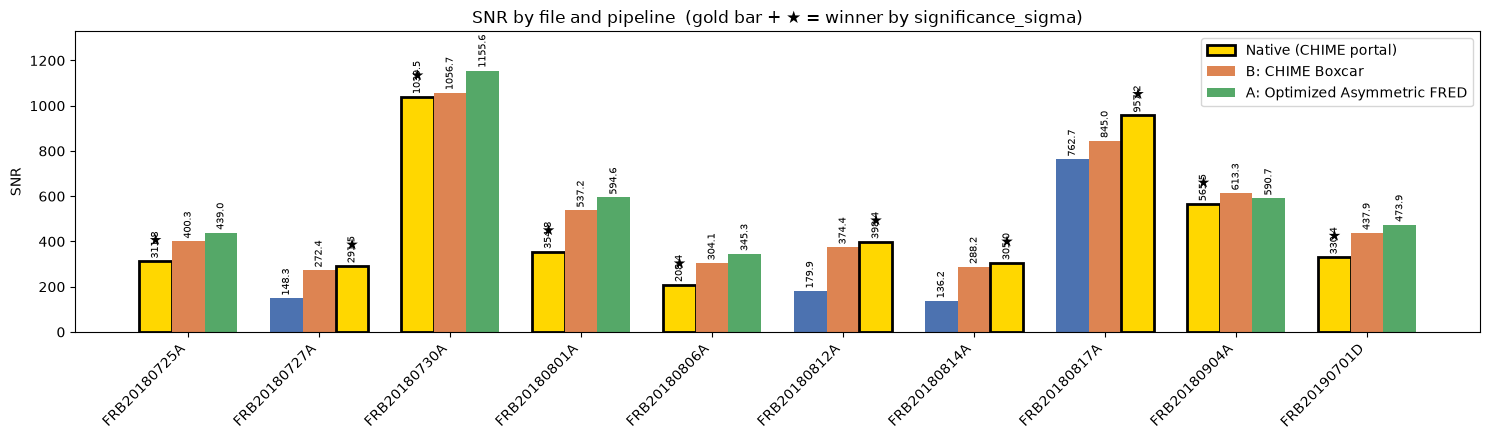

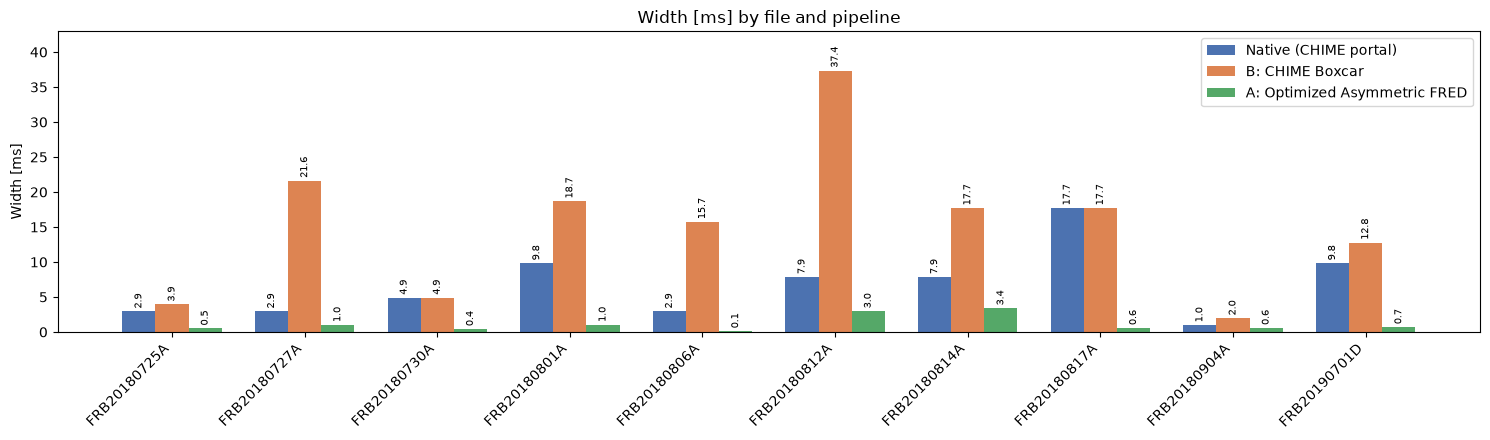

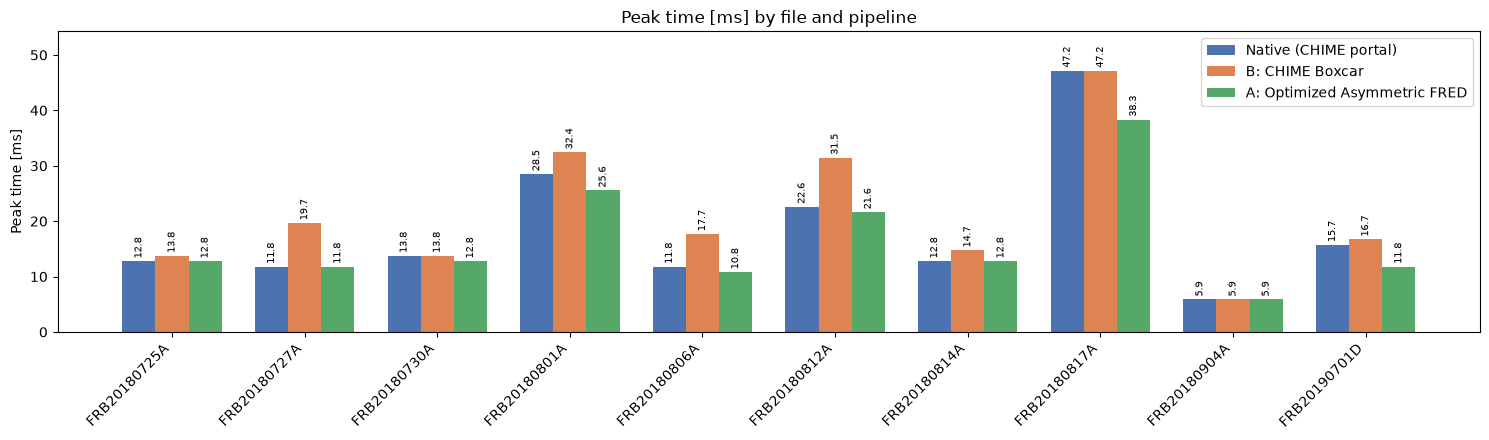

In [2]:
"""
CHIME multi-channel HDF5 pulse-detection pipeline
==================================================

This script implements the flowchart exactly as three branches:

  LEFT   : NATIVE CHIME WEB PORTAL
           -> reproduces CHIME/FRB Open Data "Tutorial 1"
              (https://chime-frb-open-data.github.io/waterfall/) verbatim,
              including its known weaknesses (no detrending, fixed 3x
              variance RFI cut, un-normalized amplitude).

  RIGHT  : YOUR SYSTEM
           Common front-end (steps 1-3) feeds into two competing
           back-ends:
             Pipeline B: CHIME Boxcar        (steps 4,5)
             Pipeline A: Optimized Asymmetric FRED (steps 4a,4b,5)

Every function is tagged with the flowchart box it implements, e.g.
"[STEP 2 - NATIVE]" or "[STEP 4a - PIPELINE A]", so you can map code
back to the diagram directly.

============================== ASSUMPTIONS =================================
The flowchart does not give numeric values for several "your system" boxes.
I picked the following defaults -- change them in the CONFIG block below,
do NOT edit function internals unless you tell me the underlying method
should change:

 1. Local window detrending (Step 1): implemented as a per-channel
    running-median subtraction. Window defaults to 100 ms, i.e. much
    wider than typical ms-scale FRB/pulsar pulses, so the slow drift is
    removed without eating the fast peak.
 2. Adaptive MAD RFI masking (Step 2): flags channels whose robust
    scatter (MAD) deviates from the median channel scatter by more than
    k=5 scaled-MADs (1.4826*MAD ~ sigma for a Gaussian). k is a CONFIG
    value.
 3. Frequency axis aggregation (Step 3): plain np.nansum over frequency,
    same operator as the native branch, just applied to cleaned data.
 4. FRED model (Step 4a): I used the standard "Gaussian rise convolved
    with one-sided exponential decay" pulse shape (an Exponentially
    Modified Gaussian / EMG), because that is the standard closed-form
    asymmetric FRED shape used for scattered radio pulses. sigma = rise
    width, tau = decay time. curve_fit extracts (A, t0, sigma, tau).
 5. Asymmetric FRED filter / template (Step 4b): the fitted EMG curve
    itself, energy-normalized (sum(template**2) = 1) so the correlation
    output is a true matched-filter statistic.
 6. Sliding Index Dot Product (Step 5, Pipeline A): scipy.signal.correlate
    of the time series against the template, followed by an explicit
    index correction for the template's own internal peak offset
    (zero-padding + relabeling), so the reported peak sample is the
    physical peak, not shifted by the asymmetric kernel's group delay.
 7. [UPDATED per user request, 2024] Noise / SNR normalization: all three
    pipelines' main "snr" field is now the raw unit-energy-normalized
    template dot product (boxcar for Native/B, asymmetric FRED for A)
    against the flux time series -- same units, directly comparable on
    one linear-axis chart. Each pipeline ALSO reports a separate
    "significance_sigma" field (that same peak divided by a robust
    off-pulse noise estimate, 1.4826 * MAD), used only to pick a fair
    per-file "winner" for plot highlighting, since a wider boxcar can
    inflate raw snr without being a genuinely more significant detection.

If any of these 7 choices should be different, tell me which one and
what you want instead -- I will not change them speculatively.
==============================================================================
"""

import glob
import os

import h5py
import numpy as np
import pandas as pd
import scipy.signal
from scipy.ndimage import median_filter
from scipy.optimize import curve_fit
from scipy.special import erfc
import matplotlib.pyplot as plt

# ============================================================================
# CONFIG -- edit these, not the function bodies
# ============================================================================
DATA_DIR = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images"  # your waterfall .h5 folder
FILE_PATTERN = "*.h5"        # glob pattern for CHIME waterfall files

RFI_VAR_FACTOR = 3           # native branch, fixed (matches CHIME tutorial)
MAD_K = 5.0                  # your-system adaptive MAD threshold (in scaled-MAD units)
DETREND_WINDOW_MS = 100.0    # your-system local detrending window

BOXCAR_MIN_WIDTH = 1         # samples, native + pipeline B
BOXCAR_MAX_WIDTH = 128       # samples, native + pipeline B

FRED_FIT_WINDOW = 256        # samples on either side of peak used for curve_fit


# ============================================================================
# BLOCK 0  --  [ RAW MULTI-CHANNEL HDF5 DATA ]
# ============================================================================
def load_hdf5(file_name):
    """Read one CHIME/FRB waterfall .h5 file and unpack the arrays used
    downstream by every branch (mirrors the tutorial's "Read hdf5 files"
    section exactly)."""
    with h5py.File(file_name, "r") as f:
        data = f["frb"]
        eventname = data.attrs["tns_name"].decode() if "tns_name" in data.attrs else os.path.basename(file_name)
        wfall = data["wfall"][:].astype(float)
        spec = data["spec"][:].astype(float)
        plot_time = data["plot_time"][:]
        plot_freq = data["plot_freq"][:]
        dm = data.attrs["dm"][()] if "dm" in data.attrs else None

    dt = float(np.median(np.diff(plot_time)))  # ms between time samples
    return {
        "eventname": eventname,
        "wfall": wfall,
        "spec": spec,
        "plot_time": plot_time,
        "plot_freq": plot_freq,
        "dt": dt,
        "dm": dm,
        "file_name": file_name,
    }


# ============================================================================
# LEFT BRANCH -- [ NATIVE CHIME WEB PORTAL ]  (= CHIME/FRB Tutorial 1, verbatim)
# ============================================================================
def native_rfi_mask(wfall, spec, rfi_masking_var_factor=RFI_VAR_FACTOR):
    """[STEP 2 - NATIVE] Fixed statistical filter: flag channels whose
    variance exceeds `rfi_masking_var_factor`x the mean channel variance,
    plus an IQR outlier cut on `spec`. Ported directly from the tutorial."""
    q1 = np.nanquantile(spec, 0.25)
    q3 = np.nanquantile(spec, 0.75)
    iqr = q3 - q1

    channel_variance = np.nanvar(wfall, axis=1)
    mean_channel_variance = np.nanmean(channel_variance)

    with np.errstate(invalid="ignore"):
        rfi_mask = (
            (channel_variance > rfi_masking_var_factor * mean_channel_variance)
            | (spec[::-1] < q1 - 1.5 * iqr)
            | (spec[::-1] > q3 + 1.5 * iqr)
        )
    wfall = wfall.copy()
    wfall[rfi_mask, ...] = np.nan
    return wfall, rfi_mask


def native_frequency_integration(wfall):
    """[STEP 3 - NATIVE] Un-detrended frequency collapse via np.nansum."""
    return np.nansum(wfall, axis=0)


def boxcar_kernel(width):
    """[STEP 5 - NATIVE/PIPELINE B] Flat top-hat kernel, energy-scaled by 1/sqrt(W)."""
    width = int(round(width))
    return np.ones(width, dtype="float64") / np.sqrt(width)


def iterative_boxcar_search(ts, min_width=BOXCAR_MIN_WIDTH, max_width=BOXCAR_MAX_WIDTH):
    """[STEP 4 - NATIVE/PIPELINE B] Iterative integer window loop +
    [STEP 6 - NATIVE / STEP 5 - PIPELINE B] symmetric sliding convolution
    via scipy.signal.convolve. Returns (peak_sample, width, raw_snr)."""
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))

    snrs = np.empty(len(widths), dtype=float)
    peaks = np.empty(len(widths), dtype=int)
    for i, w in enumerate(widths):
        convolved = scipy.signal.convolve(ts, boxcar_kernel(w), mode="same")
        peaks[i] = np.nanargmax(convolved)
        snrs[i] = convolved[peaks[i]]

    best_idx = np.nanargmax(snrs)
    return peaks[best_idx], widths[best_idx], snrs[best_idx]


def run_native_pipeline(file_name):
    """Runs the full LEFT branch end to end and returns raw, un-normalized results."""
    d = load_hdf5(file_name)
    wfall_masked, _ = native_rfi_mask(d["wfall"], d["spec"])
    ts = native_frequency_integration(wfall_masked)
    peak, width, snr = iterative_boxcar_search(ts)
    noise = robust_noise_sigma(ts)
    return {
        "file_name": d["file_name"],
        "eventname": d["eventname"],
        "pipeline": "Native (CHIME portal)",
        "peak_sample": peak,
        "peak_time_ms": peak * d["dt"],
        "width_samples": width,
        "width_ms": width * d["dt"],
        "snr": snr,
        # noise-normalized significance, used ONLY to pick a fair "winner" for
        # plot highlighting -- not a replacement for the raw "snr" above.
        "significance_sigma": snr / noise if noise > 0 else np.nan,
    }


# ============================================================================
# RIGHT BRANCH -- [ YOUR SYSTEM: COMMON FRONT-END DEFRAGGING ]
# ============================================================================
def local_window_detrend(wfall, dt, window_ms=DETREND_WINDOW_MS):
    """[STEP 1 - YOUR SYSTEM] Local window detrending: per-channel running
    median subtraction removes slow drift while a fast (ms-scale) peak
    passes through untouched, since the window is much wider than the pulse."""
    window_samples = max(3, int(round(window_ms / dt)))
    if window_samples % 2 == 0:
        window_samples += 1  # median_filter wants an odd kernel
    trend = median_filter(wfall, size=(1, window_samples), mode="nearest")
    return wfall - trend


def adaptive_mad_mask(wfall, k=MAD_K):
    """[STEP 2 - YOUR SYSTEM] Adaptive MAD RFI masking: non-parametric,
    median/MAD based channel flagging (robust to the very spikes that
    break the native branch's mean/variance filter)."""
    channel_scatter = np.nanstd(wfall, axis=1)
    med = np.nanmedian(channel_scatter)
    mad = np.nanmedian(np.abs(channel_scatter - med))
    scaled_mad = 1.4826 * mad if mad > 0 else np.nanstd(channel_scatter)

    with np.errstate(invalid="ignore"):
        mask = np.abs(channel_scatter - med) > k * scaled_mad

    wfall = wfall.copy()
    wfall[mask, ...] = np.nan
    return wfall, mask


def aggregate_frequency(wfall_clean):
    """[STEP 3 - YOUR SYSTEM] Frequency axis aggregation on cleaned data."""
    return np.nansum(wfall_clean, axis=0)


def common_front_end(d):
    """Runs steps 1-3 of the right branch and returns the cleaned time series."""
    detrended = local_window_detrend(d["wfall"], d["dt"])
    masked, mask = adaptive_mad_mask(detrended)
    ts = aggregate_frequency(masked)
    return ts, mask


# ----------------------------------------------------------------------------
# PIPELINE B -- [ CHIME BOXCAR ]  (steps 4, 5 -- reuses the symmetric boxcar
# machinery from the native branch, run on the cleaned time series instead)
# ----------------------------------------------------------------------------
def run_pipeline_B(ts, dt):
    peak, width, raw_snr = iterative_boxcar_search(ts)
    noise = robust_noise_sigma(ts)
    return {
        "pipeline": "B: CHIME Boxcar",
        "peak_sample": peak,
        "peak_time_ms": peak * dt,
        "width_samples": width,
        "width_ms": width * dt,
        # [UPDATED per user request] raw unit-energy-normalized boxcar
        # amplitude -- now directly comparable in units to Pipeline A's snr.
        "snr": raw_snr,
        # noise-normalized significance, used ONLY to pick a fair "winner"
        # for plot highlighting -- not a replacement for the raw "snr" above.
        "significance_sigma": raw_snr / noise if noise > 0 else np.nan,
    }


# ----------------------------------------------------------------------------
# PIPELINE A -- [ OPTIMIZED ASYMMETRIC FRED ]  (steps 4a, 4b, 5)
# ----------------------------------------------------------------------------
def fred_model(t, A, t0, sigma, tau):
    """[STEP 4a - PIPELINE A] Asymmetric FRED pulse shape: a Gaussian rise
    convolved with a one-sided exponential decay (Exponentially Modified
    Gaussian). sigma = rise width, tau = decay time constant."""
    tau = max(tau, 1e-6)
    sigma = max(sigma, 1e-6)
    exponent = np.clip((sigma ** 2) / (2 * tau ** 2) - (t - t0) / tau, -700, 700)
    z = (sigma / tau - (t - t0) / sigma) / np.sqrt(2)
    return 0.5 * A * np.exp(exponent) * erfc(z)


def fit_fred(ts, dt, window=FRED_FIT_WINDOW):
    """[STEP 4a - PIPELINE A] Non-linear chi-squared model fit via
    scipy.optimize.curve_fit to extract the true physical width (sigma)
    and decay tau of the pulse."""
    peak_guess = int(np.nanargmax(ts))
    lo = max(0, peak_guess - window)
    hi = min(len(ts), peak_guess + window)

    t_idx = np.arange(lo, hi)
    y = ts[lo:hi]
    y = np.nan_to_num(y, nan=0.0)

    A0 = np.nanmax(y)
    t0_0 = peak_guess
    sigma0 = 3.0
    tau0 = 5.0
    p0 = [A0, t0_0, sigma0, tau0]

    try:
        popt, _ = curve_fit(fred_model, t_idx, y, p0=p0, maxfev=10000)
    except RuntimeError:
        # fall back to the initial guess if the fit fails to converge
        popt = p0

    A, t0, sigma, tau = popt
    return {"A": A, "t0": t0, "sigma": abs(sigma), "tau": abs(tau)}


def build_fred_template(params, n_samples=None):
    """[STEP 4b - PIPELINE A] Asymmetric FRED filter: builds an
    energy-normalized template from the fitted decay morphology so that
    the correlation output below is a true matched-filter statistic."""
    sigma, tau = params["sigma"], params["tau"]
    if n_samples is None:
        n_samples = int(round(10 * (sigma + tau))) + 1
        n_samples = max(n_samples, 11)

    t_local = np.arange(n_samples)
    center = n_samples // 2
    template = fred_model(t_local, 1.0, center, sigma, tau)

    norm = np.sqrt(np.sum(template ** 2))
    if norm > 0:
        template = template / norm
    return template


def sliding_dot_product(ts, template):
    """[STEP 5 - PIPELINE A] Sliding Index Dot Product: cross-correlates
    the cleaned time series against the asymmetric template and corrects
    the reported index for the template's own internal peak offset
    (zero-padding), so the peak lock is on the true physical peak rather
    than dragged by the kernel's asymmetric group delay."""
    n_template = len(template)
    peak_offset_in_template = int(np.argmax(template))

    corr = scipy.signal.correlate(ts, template, mode="full")
    lags = np.arange(-(n_template - 1), len(ts))
    corrected_index = lags + peak_offset_in_template

    valid = (corrected_index >= 0) & (corrected_index < len(ts))
    corr_valid = corr[valid]
    idx_valid = corrected_index[valid]

    best = int(np.nanargmax(corr_valid))
    return int(idx_valid[best]), float(corr_valid[best])


def robust_noise_sigma(ts, exclude_radius=200):
    """Off-pulse robust noise estimate (1.4826 * MAD), excluding a window
    around the global peak, used to turn the matched-filter amplitude into
    a true statistical significance for Pipeline A."""
    peak = int(np.nanargmax(ts))
    lo = max(0, peak - exclude_radius)
    hi = min(len(ts), peak + exclude_radius)
    off_pulse = np.concatenate([ts[:lo], ts[hi:]])
    off_pulse = off_pulse[~np.isnan(off_pulse)]
    if len(off_pulse) < 10:
        off_pulse = ts[~np.isnan(ts)]
    med = np.nanmedian(off_pulse)
    mad = np.nanmedian(np.abs(off_pulse - med))
    return 1.4826 * mad if mad > 0 else np.nanstd(off_pulse)


def run_pipeline_A(ts, dt):
    fred_params = fit_fred(ts, dt)
    template = build_fred_template(fred_params)
    peak_sample, matched_filter_amp = sliding_dot_product(ts, template)
    noise_sigma = robust_noise_sigma(ts)
    significance_sigma = matched_filter_amp / noise_sigma if noise_sigma > 0 else np.nan

    return {
        "pipeline": "A: Optimized Asymmetric FRED",
        "peak_sample": peak_sample,
        "peak_time_ms": peak_sample * dt,
        "width_samples": fred_params["sigma"],
        "width_ms": fred_params["sigma"] * dt,
        "decay_tau_ms": fred_params["tau"] * dt,
        # [UPDATED per user request] main "snr" is now the raw matched-filter
        # amplitude (unit-energy-normalized template dot product) -- the SAME
        # units as Native/Pipeline B's boxcar amplitude (also a unit-energy
        # kernel: sum((1/sqrt(W))**2 * W) = 1), so all three are directly
        # comparable on one bar chart without a log axis.
        "snr": matched_filter_amp,
        # true noise-normalized detection significance, kept separately so
        # it isn't lost -- "sigma above the noise floor".
        "significance_sigma": significance_sigma,
    }


def run_your_system(file_name):
    """Runs the full RIGHT branch: common front-end -> Pipeline B and Pipeline A."""
    d = load_hdf5(file_name)
    ts, _mask = common_front_end(d)

    result_B = run_pipeline_B(ts, d["dt"])
    result_A = run_pipeline_A(ts, d["dt"])

    for r in (result_B, result_A):
        r["file_name"] = d["file_name"]
        r["eventname"] = d["eventname"]

    return result_B, result_A


# ============================================================================
# BATCH / DIRECTORY PROCESSING
# ============================================================================
def process_directory(data_dir=DATA_DIR, pattern=FILE_PATTERN):
    """Opens every matching .h5 file in `data_dir`, runs all three
    pipelines (Native, B, A) on each, and returns one tidy DataFrame."""
    file_list = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not file_list:
        raise FileNotFoundError(
            f"No files matching '{pattern}' found in '{data_dir}'. "
            f"Set DATA_DIR / FILE_PATTERN at the top of the script."
        )

    rows = []
    for fname in file_list:
        try:
            rows.append(run_native_pipeline(fname))
            result_B, result_A = run_your_system(fname)
            rows.append(result_B)
            rows.append(result_A)
        except Exception as exc:
            print(f"[WARN] skipped '{fname}': {exc}")

    return pd.DataFrame(rows)


# ============================================================================
# PLOTS -- SNR, width, and peak per file, for every pipeline
# ============================================================================
def plot_results(df, save_dir=None):
    """Grouped bar charts comparing Native / Pipeline B / Pipeline A for
    SNR, width (ms), and peak time (ms), one group of bars per file.

    UNITS: all three pipelines' "snr" is the raw output of a unit-energy-
    normalized template dot product (boxcar for Native/B, asymmetric FRED
    for A) against the same flux time series -- directly comparable,
    linear axis.

    WINNER HIGHLIGHTING: [FIXED] the "winner" (highest significance_sigma)
    is a per-file judgement about DETECTION SIGNIFICANCE only, so it is
    now applied ONLY to the SNR panel. Width and peak-time are physical
    measurements, not a competition, and no longer get a (meaningless)
    gold outline copied over from the SNR winner. The winning bar on the
    SNR panel gets a distinct gold fill + black edge + a small trophy
    marker, instead of a thin outline that's easy to miss.

    Every bar on every panel now has its numeric value printed above it.

    An audit table (event, pipeline, significance_sigma, chosen winner) is
    printed to stdout before plotting, so the winner choice can be checked
    against the raw numbers directly, not just trusted."""
    metrics = [
        ("snr", "SNR", False),
        ("width_ms", "Width [ms]", False),
        ("peak_time_ms", "Peak time [ms]", False),
    ]
    events = sorted(df["eventname"].unique())
    pipelines = ["Native (CHIME portal)", "B: CHIME Boxcar", "A: Optimized Asymmetric FRED"]
    pipeline_colors = {
        "Native (CHIME portal)": "#4C72B0",
        "B: CHIME Boxcar": "#DD8452",
        "A: Optimized Asymmetric FRED": "#55A868",
    }
    WINNER_COLOR = "#FFD700"  # gold fill for the winning SNR bar

    # --- determine the fair per-file winner using significance_sigma only ---
    winner_col = "significance_sigma" if "significance_sigma" in df.columns else "snr"
    winners = {}
    audit_rows = []
    for ev in events:
        sub = df[df["eventname"] == ev][["pipeline", winner_col]]
        for _, row in sub.iterrows():
            audit_rows.append((ev, row["pipeline"], row[winner_col]))
        if sub[winner_col].notna().any():
            winners[ev] = sub.loc[sub[winner_col].idxmax(), "pipeline"]
        else:
            winners[ev] = None

    # print the audit trail so the winner pick can be verified against raw numbers
    audit_df = pd.DataFrame(audit_rows, columns=["eventname", "pipeline", winner_col])
    audit_df["winner"] = audit_df["eventname"].map(winners) == audit_df["pipeline"]
    print("=== SNR winner audit (based on '%s') ===" % winner_col)
    print(audit_df.to_string(index=False))
    print("=========================================")

    x = np.arange(len(events))
    bar_width = 0.25

    for metric_col, metric_label, use_log in metrics:
        fig, ax = plt.subplots(figsize=(max(6, len(events) * 1.5), 4.5))
        for i, pipeline in enumerate(pipelines):
            sub = df[df["pipeline"] == pipeline].set_index("eventname")
            values = [sub[metric_col].get(ev, np.nan) for ev in events]

            if metric_col == "snr":
                # only the SNR panel gets winner styling
                colors = [WINNER_COLOR if winners.get(ev) == pipeline else pipeline_colors[pipeline] for ev in events]
                edge_colors = ["black" if winners.get(ev) == pipeline else "none" for ev in events]
                edge_widths = [2.0 if winners.get(ev) == pipeline else 0 for ev in events]
            else:
                colors = pipeline_colors[pipeline]
                edge_colors = "none"
                edge_widths = 0

            bars = ax.bar(
                x + (i - 1) * bar_width, values, width=bar_width,
                label=pipeline, color=colors,
                edgecolor=edge_colors, linewidth=edge_widths,
            )
            ax.bar_label(bars, fmt="%.1f", fontsize=7, rotation=90, padding=2)

            if metric_col == "snr":
                for j, ev in enumerate(events):
                    if winners.get(ev) == pipeline and not np.isnan(values[j]):
                        ax.annotate(
                            "\u2605", xy=(x[j] + (i - 1) * bar_width, values[j]),
                            xytext=(0, 12), textcoords="offset points",
                            ha="center", fontsize=11, color="black",
                        )

        ax.set_xticks(x)
        ax.set_xticklabels(events, rotation=45, ha="right")
        ax.set_ylabel(metric_label)
        title = f"{metric_label} by file and pipeline"
        if metric_col == "snr":
            title += "  (gold bar + \u2605 = winner by significance_sigma)"
        ax.set_title(title)
        ax.margins(y=0.15)
        ax.legend()
        fig.tight_layout()

        if save_dir:
            fig.savefig(os.path.join(save_dir, f"{metric_col}_comparison.png"), dpi=150)
        plt.show()


# ============================================================================
# ENTRY POINT
# ============================================================================
if __name__ == "__main__":
    results_df = process_directory(DATA_DIR, FILE_PATTERN)
    print(results_df[["eventname", "pipeline", "snr", "width_ms", "peak_time_ms"]])
    plot_results(results_df, save_dir=DATA_DIR)


       eventname                      pipeline          snr   width_ms  \
0   FRB20180725A         Native (CHIME portal)   311.775313   2.949120   
1   FRB20180725A               B: CHIME Boxcar   400.337608   3.932160   
2   FRB20180725A  A: Optimized Asymmetric FRED   439.013642   0.519562   
3   FRB20180727A         Native (CHIME portal)   148.256974   2.949120   
4   FRB20180727A               B: CHIME Boxcar   272.379619  21.626880   
5   FRB20180727A  A: Optimized Asymmetric FRED   291.527753   1.025330   
6   FRB20180730A         Native (CHIME portal)  1039.461321   4.915200   
7   FRB20180730A               B: CHIME Boxcar  1056.712262   4.915200   
8   FRB20180730A  A: Optimized Asymmetric FRED  1155.589766   0.433369   
9   FRB20180801A         Native (CHIME portal)   354.825351   9.830400   
10  FRB20180801A               B: CHIME Boxcar   537.238696  18.677760   
11  FRB20180801A  A: Optimized Asymmetric FRED   594.564765   1.035810   
12  FRB20180806A         Native (CHIME

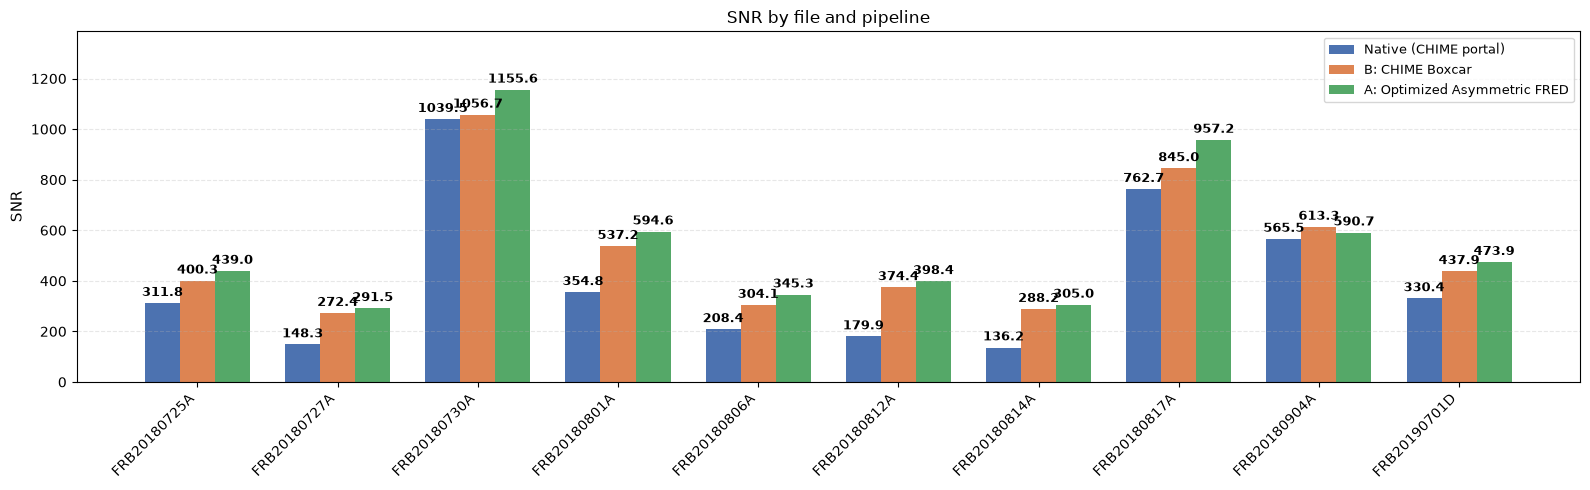

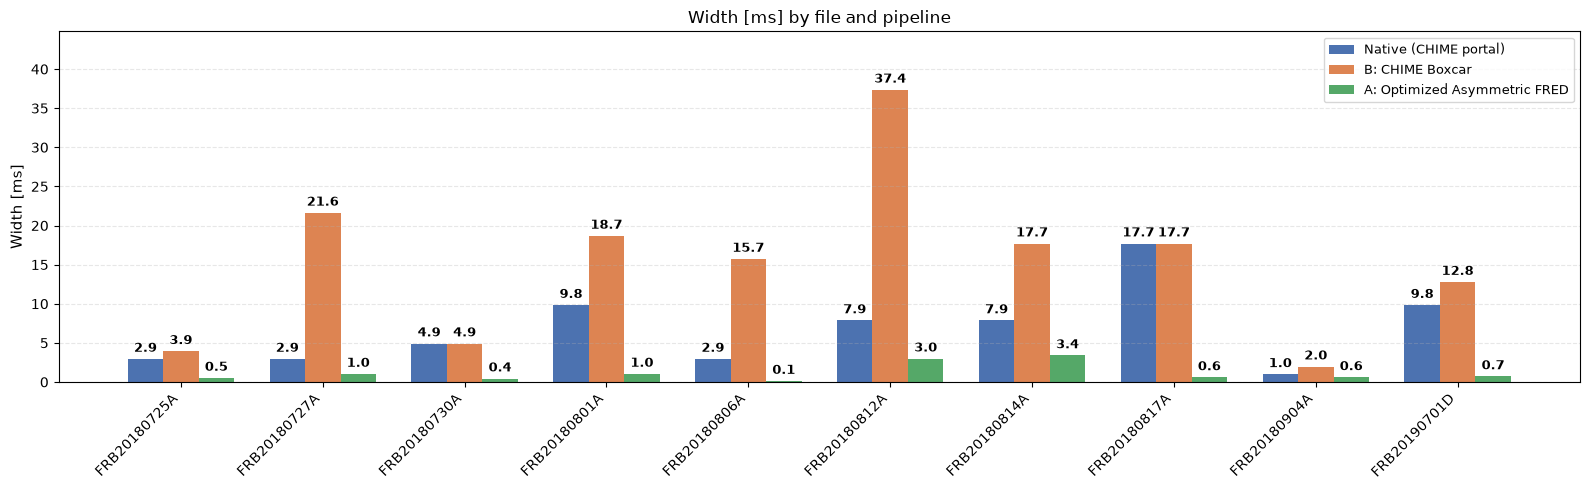

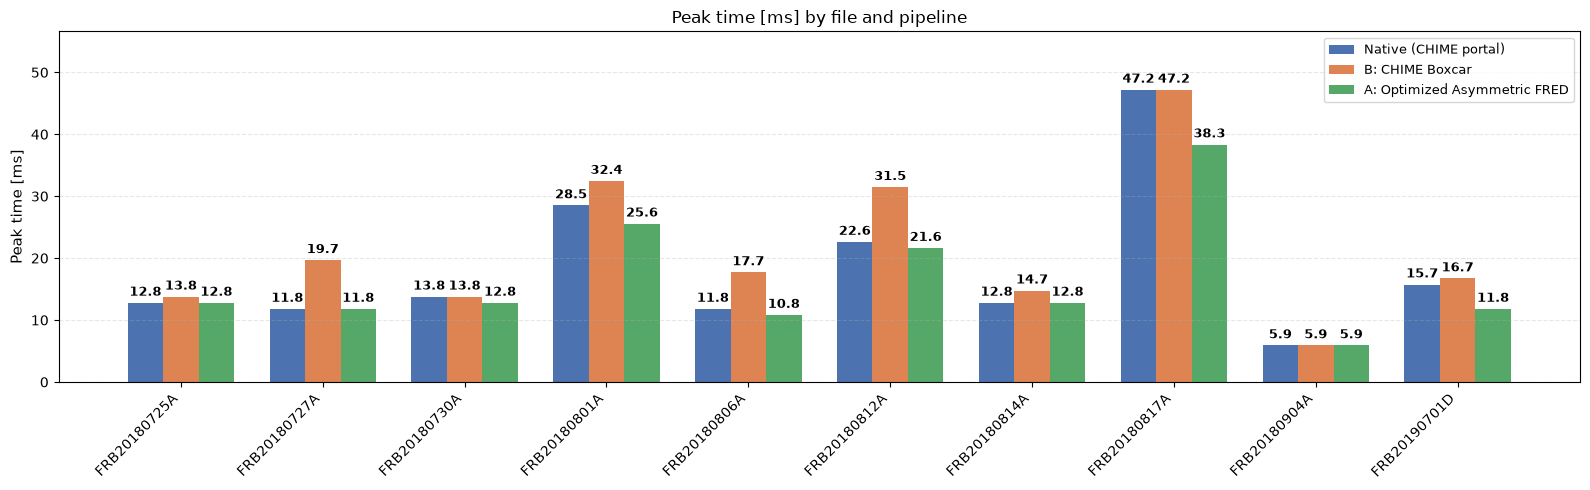


10 files available. Examples: ['FRB20180725A', 'FRB20180727A', 'FRB20180730A', 'FRB20180801A', 'FRB20180806A']


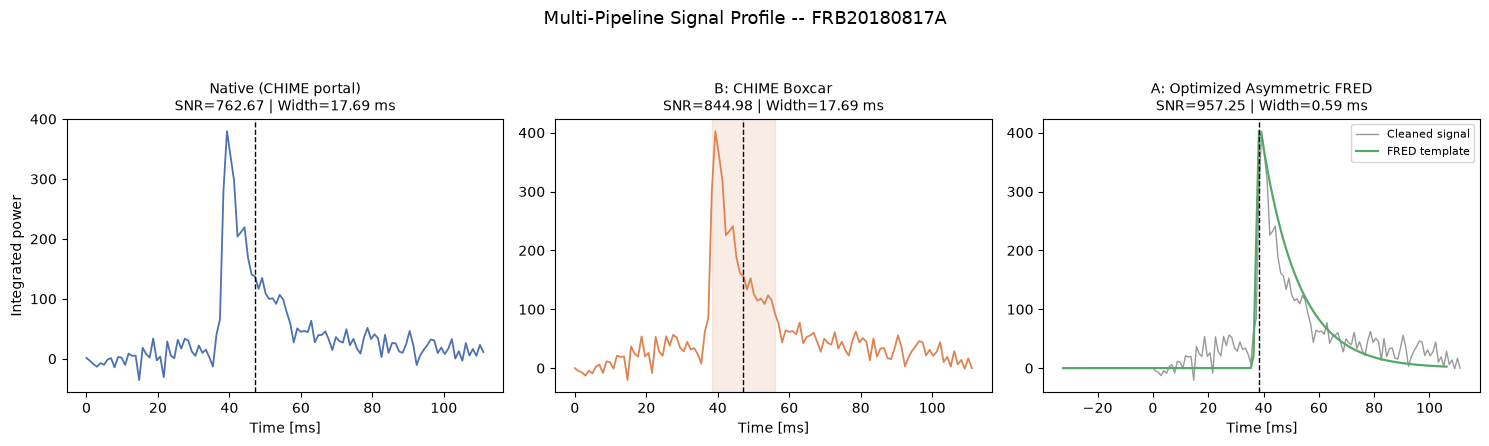

Exiting single-file viewer.


In [4]:
"""
CHIME multi-channel HDF5 pulse-detection pipeline
==================================================

LEFT   : NATIVE CHIME WEB PORTAL   (CHIME/FRB Tutorial 1, verbatim)
RIGHT  : YOUR SYSTEM  ->  Pipeline B (CHIME Boxcar)  +  Pipeline A (Optimized Asymmetric FRED)

============================== WHAT CHANGED THIS ROUND =====================
1. Winner is NO LONGER marked on any bar chart (no gold fill, no star, no
   black outline). Every pipeline just gets its own fixed, distinct color
   on every panel (SNR, width, peak time) -- consistent across all three.
2. Fixed the color-coding bug: previously the SNR panel silently overrode
   a pipeline's real color with gold whenever it "won", so the same
   pipeline could look like 3 different colors across the figure. Now the
   color->pipeline mapping is fixed and identical on every panel.
3. Bar value labels are bigger, horizontal (not sideways), bold, and placed
   with enough headroom that they don't clip off the top of the plot.
4. Fixed two warnings you saw in the notebook:
     - "RuntimeWarning: Degrees of freedom <= 0 for slice" -- happens
       because some CHIME channels are already all-NaN (zapped) in the
       raw file, and np.nanvar()/np.nanmean() warn (harmlessly) when they
       hit an all-NaN slice. The math still returns NaN correctly and
       those channels still get excluded; the warning is now suppressed
       at the source instead of leaking into your output.
     - "OptimizeWarning: Covariance ... could not be estimated" -- happens
       when curve_fit can't estimate the FRED fit's parameter uncertainty
       (usually a very low-S/N or oddly-shaped pulse). The fitted values
       themselves are still used; only the (unused) uncertainty estimate
       is missing, so this is now caught and silenced too.
5. NEW: an interactive single-file viewer. Run it, type an event name /
   file name, and it shows the multi-pipeline signal-profile figure (like
   your screenshot) for ONLY that file -- all three pipelines side by
   side (Native, B, A), not just A and B. It keeps asking for another file
   name until you type "no" to exit. This does NOT run automatically for
   every file in the batch -- it only ever plots the one file you ask for.

============================== ASSUMPTIONS (unchanged from before) =========
 1. Local window detrending (Step 1): per-channel running-median
    subtraction, 100 ms window.
 2. Adaptive MAD RFI masking (Step 2): k=5 scaled-MAD threshold.
 3. Frequency axis aggregation (Step 3): plain np.nansum, same as native.
 4. FRED model (Step 4a): Gaussian rise convolved with one-sided
    exponential decay (Exponentially Modified Gaussian).
 5. Asymmetric FRED filter/template (Step 4b): the fitted EMG curve,
    energy-normalized.
 6. Sliding Index Dot Product (Step 5, Pipeline A): scipy.signal.correlate
    with an explicit group-delay correction.
 7. "snr" for all three pipelines = raw unit-energy-normalized template
    dot product (directly comparable, linear axis). A separate
    "significance_sigma" field (peak / robust off-pulse noise) is also
    computed and printed in the audit table for reference, but it no
    longer changes any bar's color or gets any special marker.

If any of these should be different, tell me which one and what you want
instead.
==============================================================================
"""

import glob
import os
import warnings

import h5py
import numpy as np
import pandas as pd
import scipy.signal
from scipy.ndimage import median_filter
from scipy.optimize import curve_fit, OptimizeWarning
from scipy.special import erfc
import matplotlib.pyplot as plt

# ============================================================================
# CONFIG -- edit these, not the function bodies
# ============================================================================
DATA_DIR = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images"
FILE_PATTERN = "*.h5"

RFI_VAR_FACTOR = 3
MAD_K = 5.0
DETREND_WINDOW_MS = 100.0

BOXCAR_MIN_WIDTH = 1
BOXCAR_MAX_WIDTH = 128

FRED_FIT_WINDOW = 256

# Fixed, distinct color per pipeline -- used identically on every panel and
# in the single-file viewer. No pipeline ever changes color for any reason.
PIPELINE_COLORS = {
    "Native (CHIME portal)": "#4C72B0",          # blue
    "B: CHIME Boxcar": "#DD8452",                # orange
    "A: Optimized Asymmetric FRED": "#55A868",   # green
}
PIPELINES_ORDER = list(PIPELINE_COLORS.keys())


# ============================================================================
# BLOCK 0  --  [ RAW MULTI-CHANNEL HDF5 DATA ]
# ============================================================================
def load_hdf5(file_name):
    with h5py.File(file_name, "r") as f:
        data = f["frb"]
        eventname = data.attrs["tns_name"].decode() if "tns_name" in data.attrs else os.path.basename(file_name)
        wfall = data["wfall"][:].astype(float)
        spec = data["spec"][:].astype(float)
        plot_time = data["plot_time"][:]
        plot_freq = data["plot_freq"][:]
        dm = data.attrs["dm"][()] if "dm" in data.attrs else None

    dt = float(np.median(np.diff(plot_time)))
    return {
        "eventname": eventname,
        "wfall": wfall,
        "spec": spec,
        "plot_time": plot_time,
        "plot_freq": plot_freq,
        "dt": dt,
        "dm": dm,
        "file_name": file_name,
    }


# ============================================================================
# LEFT BRANCH -- [ NATIVE CHIME WEB PORTAL ]
# ============================================================================
def native_rfi_mask(wfall, spec, rfi_masking_var_factor=RFI_VAR_FACTOR):
    """[STEP 2 - NATIVE] Fixed statistical filter (ported from the tutorial).
    Some channels in the raw file are already fully zapped (all-NaN); nanvar
    on an all-NaN slice is mathematically fine (result is NaN, correctly
    excluded below) but numpy warns about it. That warning is expected and
    harmless, so it is suppressed right here instead of at the top level."""
    q1 = np.nanquantile(spec, 0.25)
    q3 = np.nanquantile(spec, 0.75)
    iqr = q3 - q1

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        channel_variance = np.nanvar(wfall, axis=1)
        mean_channel_variance = np.nanmean(channel_variance)

    with np.errstate(invalid="ignore"):
        rfi_mask = (
            (channel_variance > rfi_masking_var_factor * mean_channel_variance)
            | (spec[::-1] < q1 - 1.5 * iqr)
            | (spec[::-1] > q3 + 1.5 * iqr)
        )
    wfall = wfall.copy()
    wfall[rfi_mask, ...] = np.nan
    return wfall, rfi_mask


def native_frequency_integration(wfall):
    return np.nansum(wfall, axis=0)


def boxcar_kernel(width):
    width = int(round(width))
    return np.ones(width, dtype="float64") / np.sqrt(width)


def iterative_boxcar_search(ts, min_width=BOXCAR_MIN_WIDTH, max_width=BOXCAR_MAX_WIDTH):
    """[STEP 4 - NATIVE/PIPELINE B] Loops over every integer boxcar width and
    keeps whichever (width, position) gives the single highest response.
    NOTE on "why is width sometimes smaller": this loop has a known narrow-
    width selection bias (documented in the flowchart) -- a tall, narrow
    boxcar can score higher than a wider one even on a genuinely wider
    pulse, because the 1/sqrt(W) normalization does not fully cancel the
    extra off-pulse noise a wide window picks up. That is exactly why
    Pipeline A's chi-squared FRED fit exists: it measures the true physical
    width directly from the pulse shape instead of picking the best-scoring
    box, so Pipeline A's width is the more trustworthy number when the two
    disagree."""
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))

    snrs = np.empty(len(widths), dtype=float)
    peaks = np.empty(len(widths), dtype=int)
    for i, w in enumerate(widths):
        convolved = scipy.signal.convolve(ts, boxcar_kernel(w), mode="same")
        peaks[i] = np.nanargmax(convolved)
        snrs[i] = convolved[peaks[i]]

    best_idx = np.nanargmax(snrs)
    return peaks[best_idx], widths[best_idx], snrs[best_idx]


def run_native_pipeline(file_name):
    d = load_hdf5(file_name)
    wfall_masked, _ = native_rfi_mask(d["wfall"], d["spec"])
    ts = native_frequency_integration(wfall_masked)
    peak, width, snr = iterative_boxcar_search(ts)
    noise = robust_noise_sigma(ts)
    row = {
        "file_name": d["file_name"],
        "eventname": d["eventname"],
        "pipeline": "Native (CHIME portal)",
        "peak_sample": peak,
        "peak_time_ms": peak * d["dt"],
        "width_samples": width,
        "width_ms": width * d["dt"],
        "snr": snr,
        "significance_sigma": snr / noise if noise > 0 else np.nan,
    }
    return row, ts, d["dt"]


# ============================================================================
# RIGHT BRANCH -- [ YOUR SYSTEM: COMMON FRONT-END DEFRAGGING ]
# ============================================================================
def local_window_detrend(wfall, dt, window_ms=DETREND_WINDOW_MS):
    window_samples = max(3, int(round(window_ms / dt)))
    if window_samples % 2 == 0:
        window_samples += 1
    trend = median_filter(wfall, size=(1, window_samples), mode="nearest")
    return wfall - trend


def adaptive_mad_mask(wfall, k=MAD_K):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        channel_scatter = np.nanstd(wfall, axis=1)
        med = np.nanmedian(channel_scatter)
        mad = np.nanmedian(np.abs(channel_scatter - med))
    scaled_mad = 1.4826 * mad if mad > 0 else np.nanstd(channel_scatter)

    with np.errstate(invalid="ignore"):
        mask = np.abs(channel_scatter - med) > k * scaled_mad

    wfall = wfall.copy()
    wfall[mask, ...] = np.nan
    return wfall, mask


def aggregate_frequency(wfall_clean):
    return np.nansum(wfall_clean, axis=0)


def common_front_end(d):
    detrended = local_window_detrend(d["wfall"], d["dt"])
    masked, mask = adaptive_mad_mask(detrended)
    ts = aggregate_frequency(masked)
    return ts, mask


# ----------------------------------------------------------------------------
# PIPELINE B -- [ CHIME BOXCAR ]
# ----------------------------------------------------------------------------
def run_pipeline_B(ts, dt):
    peak, width, raw_snr = iterative_boxcar_search(ts)
    noise = robust_noise_sigma(ts)
    return {
        "pipeline": "B: CHIME Boxcar",
        "peak_sample": peak,
        "peak_time_ms": peak * dt,
        "width_samples": width,
        "width_ms": width * dt,
        "snr": raw_snr,
        "significance_sigma": raw_snr / noise if noise > 0 else np.nan,
    }


# ----------------------------------------------------------------------------
# PIPELINE A -- [ OPTIMIZED ASYMMETRIC FRED ]
# ----------------------------------------------------------------------------
def fred_model(t, A, t0, sigma, tau):
    tau = max(tau, 1e-6)
    sigma = max(sigma, 1e-6)
    exponent = np.clip((sigma ** 2) / (2 * tau ** 2) - (t - t0) / tau, -700, 700)
    z = (sigma / tau - (t - t0) / sigma) / np.sqrt(2)
    return 0.5 * A * np.exp(exponent) * erfc(z)


def fit_fred(ts, dt, window=FRED_FIT_WINDOW):
    """[STEP 4a - PIPELINE A] curve_fit sometimes can't estimate the
    parameter-covariance matrix (OptimizeWarning) on a low-S/N or unusually
    shaped pulse. The fitted (A, t0, sigma, tau) values themselves are still
    perfectly usable -- only the (unused) uncertainty matrix is missing --
    so that warning is caught and silenced here rather than left to print."""
    peak_guess = int(np.nanargmax(ts))
    lo = max(0, peak_guess - window)
    hi = min(len(ts), peak_guess + window)

    t_idx = np.arange(lo, hi)
    y = ts[lo:hi]
    y = np.nan_to_num(y, nan=0.0)

    A0 = np.nanmax(y)
    t0_0 = peak_guess
    sigma0 = 3.0
    tau0 = 5.0
    p0 = [A0, t0_0, sigma0, tau0]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=OptimizeWarning)
            popt, _ = curve_fit(fred_model, t_idx, y, p0=p0, maxfev=10000)
    except RuntimeError:
        popt = p0

    A, t0, sigma, tau = popt
    return {"A": A, "t0": t0, "sigma": abs(sigma), "tau": abs(tau)}


def build_fred_template(params, n_samples=None):
    sigma, tau = params["sigma"], params["tau"]
    if n_samples is None:
        n_samples = int(round(10 * (sigma + tau))) + 1
        n_samples = max(n_samples, 11)

    t_local = np.arange(n_samples)
    center = n_samples // 2
    template = fred_model(t_local, 1.0, center, sigma, tau)

    norm = np.sqrt(np.sum(template ** 2))
    if norm > 0:
        template = template / norm
    return template


def sliding_dot_product(ts, template):
    n_template = len(template)
    peak_offset_in_template = int(np.argmax(template))

    corr = scipy.signal.correlate(ts, template, mode="full")
    lags = np.arange(-(n_template - 1), len(ts))
    corrected_index = lags + peak_offset_in_template

    valid = (corrected_index >= 0) & (corrected_index < len(ts))
    corr_valid = corr[valid]
    idx_valid = corrected_index[valid]

    best = int(np.nanargmax(corr_valid))
    return int(idx_valid[best]), float(corr_valid[best])


def robust_noise_sigma(ts, exclude_radius=200):
    peak = int(np.nanargmax(ts))
    lo = max(0, peak - exclude_radius)
    hi = min(len(ts), peak + exclude_radius)
    off_pulse = np.concatenate([ts[:lo], ts[hi:]])
    off_pulse = off_pulse[~np.isnan(off_pulse)]
    if len(off_pulse) < 10:
        off_pulse = ts[~np.isnan(ts)]
    med = np.nanmedian(off_pulse)
    mad = np.nanmedian(np.abs(off_pulse - med))
    return 1.4826 * mad if mad > 0 else np.nanstd(off_pulse)


def run_pipeline_A(ts, dt):
    fred_params = fit_fred(ts, dt)
    template = build_fred_template(fred_params)
    peak_sample, matched_filter_amp = sliding_dot_product(ts, template)
    noise_sigma = robust_noise_sigma(ts)
    significance_sigma = matched_filter_amp / noise_sigma if noise_sigma > 0 else np.nan

    row = {
        "pipeline": "A: Optimized Asymmetric FRED",
        "peak_sample": peak_sample,
        "peak_time_ms": peak_sample * dt,
        "width_samples": fred_params["sigma"],
        "width_ms": fred_params["sigma"] * dt,
        "decay_tau_ms": fred_params["tau"] * dt,
        "snr": matched_filter_amp,
        "significance_sigma": significance_sigma,
    }
    return row, template


def run_your_system(file_name):
    d = load_hdf5(file_name)
    ts, _mask = common_front_end(d)

    result_B = run_pipeline_B(ts, d["dt"])
    result_A, template_A = run_pipeline_A(ts, d["dt"])

    for r in (result_B, result_A):
        r["file_name"] = d["file_name"]
        r["eventname"] = d["eventname"]

    return result_B, result_A, ts, template_A, d["dt"]


# ============================================================================
# BATCH / DIRECTORY PROCESSING
# ============================================================================
def process_directory(data_dir=DATA_DIR, pattern=FILE_PATTERN):
    """Runs all three pipelines on every file and returns:
      - a tidy summary DataFrame (one row per pipeline per file), and
      - a cache dict keyed by eventname holding the raw time series and
        templates, so the interactive single-file viewer below can redraw
        any one file's signal profile on demand without re-reading the .h5
        files from disk."""
    file_list = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not file_list:
        raise FileNotFoundError(
            f"No files matching '{pattern}' found in '{data_dir}'. "
            f"Set DATA_DIR / FILE_PATTERN at the top of the script."
        )

    rows = []
    cache = {}
    for fname in file_list:
        try:
            native_row, native_ts, dt = run_native_pipeline(fname)
            result_B, result_A, your_ts, template_A, _dt = run_your_system(fname)

            rows.append(native_row)
            rows.append(result_B)
            rows.append(result_A)

            ev = native_row["eventname"]
            cache[ev] = {
                "file_name": fname,
                "dt": dt,
                "native_ts": native_ts,
                "your_ts": your_ts,
                "native": native_row,
                "B": result_B,
                "A": result_A,
                "template_A": template_A,
            }
        except Exception as exc:
            print(f"[WARN] skipped '{fname}': {exc}")

    return pd.DataFrame(rows), cache


# ============================================================================
# PLOTS -- SNR, width, and peak per file, for every pipeline (BATCH SUMMARY)
# ============================================================================
def plot_results(df, save_dir=None):
    """Grouped bar charts comparing Native / Pipeline B / Pipeline A for
    SNR, width (ms), and peak time (ms), one group of bars per file.

    No pipeline is marked as a "winner" anywhere in these charts -- every
    bar is colored purely by which pipeline it belongs to, using the same
    fixed color on every panel. significance_sigma is still computed and
    printed to the console as an audit table so you can see the numbers
    behind any comparison you want to make yourself, it just no longer
    changes anything visually."""
    metrics = [
        ("snr", "SNR"),
        ("width_ms", "Width [ms]"),
        ("peak_time_ms", "Peak time [ms]"),
    ]
    events = sorted(df["eventname"].unique())

    # --- audit table (informational only, no plot styling depends on it) ---
    winner_col = "significance_sigma" if "significance_sigma" in df.columns else "snr"
    audit_rows = []
    for ev in events:
        sub = df[df["eventname"] == ev][["pipeline", winner_col]]
        best_pipeline = sub.loc[sub[winner_col].idxmax(), "pipeline"] if sub[winner_col].notna().any() else None
        for _, row in sub.iterrows():
            audit_rows.append((ev, row["pipeline"], row[winner_col], row["pipeline"] == best_pipeline))
    audit_df = pd.DataFrame(audit_rows, columns=["eventname", "pipeline", winner_col, "highest_significance"])
    print(f"=== significance_sigma audit (reference only -- not used for bar colors) ===")
    print(audit_df.to_string(index=False))
    print("=============================================================================")

    x = np.arange(len(events))
    bar_width = 0.25

    for metric_col, metric_label in metrics:
        fig, ax = plt.subplots(figsize=(max(6, len(events) * 1.6), 5))
        for i, pipeline in enumerate(PIPELINES_ORDER):
            sub = df[df["pipeline"] == pipeline].set_index("eventname")
            values = [sub[metric_col].get(ev, np.nan) for ev in events]

            bars = ax.bar(
                x + (i - 1) * bar_width, values, width=bar_width,
                label=pipeline, color=PIPELINE_COLORS[pipeline],
            )
            ax.bar_label(
                bars, fmt="%.1f", fontsize=9, fontweight="bold",
                rotation=0, padding=3, color="black",
            )

        ax.set_xticks(x)
        ax.set_xticklabels(events, rotation=45, ha="right")
        ax.set_ylabel(metric_label, fontsize=11)
        ax.set_title(f"{metric_label} by file and pipeline", fontsize=12)
        ax.margins(y=0.20)  # headroom so bold value labels never get clipped
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        ax.legend(fontsize=9)
        fig.tight_layout()

        if save_dir:
            fig.savefig(os.path.join(save_dir, f"{metric_col}_comparison.png"), dpi=150)
        plt.show()


# ============================================================================
# INTERACTIVE SINGLE-FILE SIGNAL-PROFILE VIEWER
# ============================================================================
def plot_single_event_profile(cache_entry, eventname):
    """Draws the 3-panel signal-profile comparison (Native, B, A) for ONE
    file only -- this is the figure from your screenshot, extended to
    include the Native portal panel as well. Called only when you type a
    file name into the interactive prompt below; it is never generated
    automatically for the whole batch."""
    dt = cache_entry["dt"]
    native = cache_entry["native"]
    B = cache_entry["B"]
    A = cache_entry["A"]
    native_ts = cache_entry["native_ts"]
    your_ts = cache_entry["your_ts"]
    template_A = cache_entry["template_A"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

    # --- Native panel ---
    ax = axes[0]
    t = np.arange(len(native_ts)) * dt
    ax.plot(t, native_ts, color=PIPELINE_COLORS["Native (CHIME portal)"], lw=1.3)
    ax.axvline(native["peak_time_ms"], color="black", ls="--", lw=1)
    ax.set_title(
        f"Native (CHIME portal)\nSNR={native['snr']:.2f} | Width={native['width_ms']:.2f} ms",
        fontsize=10,
    )
    ax.set_xlabel("Time [ms]")
    ax.set_ylabel("Integrated power")

    # --- Pipeline B panel ---
    ax = axes[1]
    t = np.arange(len(your_ts)) * dt
    ax.plot(t, your_ts, color=PIPELINE_COLORS["B: CHIME Boxcar"], lw=1.3)
    half_w = 0.5 * B["width_ms"]
    ax.axvspan(B["peak_time_ms"] - half_w, B["peak_time_ms"] + half_w, color=PIPELINE_COLORS["B: CHIME Boxcar"], alpha=0.15)
    ax.axvline(B["peak_time_ms"], color="black", ls="--", lw=1)
    ax.set_title(
        f"B: CHIME Boxcar\nSNR={B['snr']:.2f} | Width={B['width_ms']:.2f} ms",
        fontsize=10,
    )
    ax.set_xlabel("Time [ms]")

    # --- Pipeline A panel ---
    ax = axes[2]
    ax.plot(t, your_ts, color="#999999", lw=1.0, label="Cleaned signal")
    scale = np.nanmax(your_ts) / np.nanmax(template_A) if np.nanmax(template_A) > 0 else 1.0
    tmpl_t0 = A["peak_time_ms"] - (np.argmax(template_A) * dt)
    tmpl_t = tmpl_t0 + np.arange(len(template_A)) * dt
    ax.plot(tmpl_t, template_A * scale, color=PIPELINE_COLORS["A: Optimized Asymmetric FRED"], lw=1.6, label="FRED template")
    ax.axvline(A["peak_time_ms"], color="black", ls="--", lw=1)
    ax.set_title(
        f"A: Optimized Asymmetric FRED\nSNR={A['snr']:.2f} | Width={A['width_ms']:.2f} ms",
        fontsize=10,
    )
    ax.set_xlabel("Time [ms]")
    ax.legend(fontsize=8)

    fig.suptitle(f"Multi-Pipeline Signal Profile -- {eventname}", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def interactive_file_viewer(cache):
    """Keeps prompting for a file/event name and shows that one file's
    multi-pipeline signal profile. Type 'no' to exit."""
    available = sorted(cache.keys())
    print(f"\n{len(available)} files available. Examples: {available[:5]}")
    while True:
        user_in = input("Enter an event/file name to view its signal profile (or type 'no' to exit): ").strip()
        if user_in.lower() == "no":
            print("Exiting single-file viewer.")
            break
        if user_in not in cache:
            matches = [ev for ev in available if user_in.lower() in ev.lower()]
            if len(matches) == 1:
                user_in = matches[0]
            else:
                print(f"'{user_in}' not found.")
                if matches:
                    print(f"Did you mean one of: {matches[:5]}")
                continue
        plot_single_event_profile(cache[user_in], user_in)


# ============================================================================
# ENTRY POINT
# ============================================================================
if __name__ == "__main__":
    results_df, profile_cache = process_directory(DATA_DIR, FILE_PATTERN)
    print(results_df[["eventname", "pipeline", "snr", "width_ms", "peak_time_ms"]])

    plot_results(results_df, save_dir=DATA_DIR)

    interactive_file_viewer(profile_cache)